In [1]:
import sys, os; sys.path.insert(0, os.path.join("..", "src")) if os.path.basename(os.getcwd())=="notebooks" else sys.path.insert(0, "src")
import config, data_layer, econometrics as ek, validate, outputs

# FR07 — Xarici ticarət və tədiyə balansı

Mal və xidmətlərin idxal-ixracının əsas göstəriciləri, strukturu və tədiyə balansının
proqnozlaşdırılması (MİİS §15.5.1, bənd 2.4.1.13.-14.; hüquqi əsas — Nazirlər Kabinetinin
24.05.2004 tarixli 75 nömrəli qərarı, bənd 2.4.1).

## 1. Tələb

**Spesifikasiyanın mətni (§15.5.1, FR7):** "Mal və xidmətlərin idxal-ixracının əsas göstəriciləri,
strukturu, tədiyə balansının proqnozlaşdırılması."

Tələb üç ayrı işi birləşdirir. Birincisi, **əsas göstəricilər** — malların ixracı və idxalı,
xidmətlərin ixracı və idxalı — mln ABŞ dolları ilə, ödəniş balansı metodologiyasında (BPM6)
proqnozlaşdırılmalıdır. İkincisi, **struktur** tələb olunur: ticarət axınları neft-qaz və
qeyri neft-qaz hissələrinə ayrılmalıdır, çünki Azərbaycanın xarici ticarətində bu iki hissə
tamamilə fərqli qanunauyğunluqla hərəkət edir — biri dünya qiymət dövrü ilə, digəri daxili
tələb və tərəfdaş iqtisadiyyatların artımı ilə. Üçüncüsü, **balanslar** eyniliklə qapanmalıdır:
ticarət balansı, xidmətlər balansı və onların cari hesabla əlaqəsi hər il üçün yoxlanılan
mühasibat münasibətidir, ayrıca qiymətləndirilən kəmiyyət deyil.

İcra ardıcıllığında (BUILD_CONTEXT §D2) bu dəftər FR5 (neftin dünya qiyməti), FR9 (inflyasiya),
FR10 (məzənnə) və FR1 (ÜDM nüvəsi) mərhələlərindən sonra yerləşir: neft ixracının dəyəri Brent
yolundan, idxal daxili absorbsiyanın (istehlak + investisiya) nüvədə həll olunmuş yolundan,
xidmət axınları isə qeyri-neft sektorunun real artımından qidalanır. Bu dəftərin yazdığı sıralar
öz növbəsində FR11 (struktur təhlili) və FR12 (tədiyə balansının konsolidasiyası) mərhələlərinin
girişidir.

## 2. Məlumat

Bütün ticarət və tədiyə balansı sıraları əsas iş kitabının **Tədiyyə Balansı** vərəqindən
oxunur; ölçü vahidi mln ABŞ dollarıdır və əhatə 2010–2025-dir (n = 16). Faktiki dəyərlərə yalnız
`data_layer.actuals(...)` vasitəsilə müraciət olunur və bu funksiya heç bir halda 2025-dən sonrakı
il qaytarmır.

| `series_code` | Təsvir | Vahid | Vərəq, sətir | Əhatə |
|---|---|---|---|---|
| `exp_goods` | Malların ixracı (FOB) | mln USD | Tədiyyə Balansı, 6 | 2010–2025 |
| `exp_goods_oil` | Malların ixracı — neft-qaz sektoru | mln USD | Tədiyyə Balansı, 7 | 2010–2025 |
| `exp_goods_nonoil` | Malların ixracı — qeyri neft-qaz sektoru | mln USD | Tədiyyə Balansı, 8 | 2010–2025 |
| `imp_goods` | Malların idxalı (FOB) | mln USD | Tədiyyə Balansı, 9 | 2010–2025 |
| `imp_goods_oil` | Malların idxalı — neft-qaz sektoru | mln USD | Tədiyyə Balansı, 10 | 2010–2025 |
| `imp_goods_nonoil` | Malların idxalı — qeyri neft-qaz sektoru | mln USD | Tədiyyə Balansı, 11 | 2010–2025 |
| `exp_services` | Xidmətlərin ixracı | mln USD | Tədiyyə Balansı, 14 | 2010–2025 |
| `imp_services` | Xidmətlərin idxalı | mln USD | Tədiyyə Balansı, 34 | 2010–2025 |
| `trade_balance` | Xarici ticarət balansı | mln USD | Tədiyyə Balansı, 5 | 2010–2025 |
| `services_balance` | Xidmətlər balansı | mln USD | Tədiyyə Balansı, 13 | 2010–2025 |
| `current_account` | Cari əməliyyatlar hesabı | mln USD | Tədiyyə Balansı, 3 | 2010–2025 |
| `oil_export_price` | Neftin ixrac qiyməti | USD/barel | Neft-Qaz sektoru, 10 | 1997–2025 |
| `brent_usd` | Neftin dünya bazarında qiyməti (Brent) | USD/barel | Neft-Qaz sektoru, 11 | 1991–2025 |
| `partner_gdp_realg` | Tərəfdaş ölkələrin ÜDM artımı | % | `external_block_annual.csv` (IMF WEO) | 2000–2025 |
| `reer` (xarici blok) | Real Effektiv Məzənnə (REER) | indeks | `external_block_annual.csv` | 2000–2025 |

Proqnoz üfüqünün girişləri vahid fərziyyə dəstindən (`data/assumptions.csv`) götürülür:
`brent_usd` (FR5), `oil_realg` (Nazirliyin hasilat planı, ekzogen), `nonoil_realg` (FR1 nüvəsi),
`g_cons_core` və `g_inv_core` (FR1 nüvəsi — absorbsiya), `partner_gdp_realg` (IMF WEO).
Nazirliyin 2026–2030 Proqnoz sütunları yalnız `ministry_baseline(...)` vasitəsilə, müqayisə üçün
oxunur.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import Math, display

pd.set_option("display.width", 220)
LA, FY = config.LAST_ACTUAL, list(config.FY)          # 2025 və 2026–2030
H = len(FY)

CODES = ["exp_goods_oil", "exp_goods_nonoil", "imp_goods_oil", "imp_goods_nonoil",
         "exp_services", "imp_services"]
AGG = ["exp_goods", "imp_goods", "trade_balance", "services_balance"]

S = {c: data_layer.actuals(c) for c in CODES + AGG + ["current_account", "primary_income",
                                                      "secondary_income"]}
pe = data_layer.actuals("oil_export_price")           # neftin ixrac qiyməti, USD/barel
brent = data_layer.actuals("brent_usd")               # FR5-in faktiki sırası
oilg = data_layer.actuals("oil_realg")                # neft-qaz sektorunun real artımı
nong = data_layer.actuals("nonoil_realg")             # qeyri-neft sektorunun real artımı
partner = data_layer.actuals("partner_gdp_realg")     # ekzogen: tərəfdaş ölkələrin artımı

ext = data_layer.external_block().set_index("year")
reer_hist = ext["reer"].loc[:LA]                      # REER — yalnız faktiki hissə
neer_hist = ext["neer"].loc[:LA]

hist = pd.DataFrame({c: S[c] for c in CODES + AGG})
print("Ticarət və xidmət axınları, mln USD:")
print(hist.round(0).to_string())
print(f"\nəhatə: {int(hist.index.min())}–{int(hist.index.max())}, n = {len(hist)}")

Ticarət və xidmət axınları, mln USD:
      exp_goods_oil  exp_goods_nonoil  imp_goods_oil  imp_goods_nonoil  exp_services  imp_services  exp_goods  imp_goods  trade_balance  services_balance
year                                                                                                                                                     
2010        25108.0            1368.0          838.0            5908.0        2065.0        3799.0    26476.0     6746.0        19730.0           -1734.0
2011        32871.0            1624.0         1135.0            9032.0        2720.0        5715.0    34495.0    10166.0        24328.0           -2995.0
2012        30701.0            1934.0         1043.0            9375.0        4281.0        7205.0    32634.0    10417.0        22217.0           -2924.0
2013        30003.0            1773.0         1167.0            9989.0        4131.0        8319.0    31776.0    11156.0        20621.0           -4188.0
2014        26628.0            1633.0  

**Nəşr olunmuş məlumatın daxili uzlaşması.** Modelləşdirmədən əvvəl mənbənin öz eynilikləri
yoxlanılır: alt komponentlərin cəmi məcmu göstəriciyə, balanslar isə axınların fərqinə bərabər
olmalıdır. Bu yoxlama olmadan proqnozun eyniliklə qapanmasının heç bir mənası olmazdı, çünki
uyğunsuzluq bazadan gələrdi.

In [3]:
v0 = validate.Verifier("FR07 — nəşr olunmuş tədiyə balansının daxili uzlaşması (2010–2025)")
v0.identity("ixrac = neft + qeyri-neft", S["exp_goods"], S["exp_goods_oil"] + S["exp_goods_nonoil"], tol=1e-6)
v0.identity("idxal = neft + qeyri-neft", S["imp_goods"], S["imp_goods_oil"] + S["imp_goods_nonoil"], tol=1e-6)
v0.identity("ticarət balansı = ixrac − idxal", S["trade_balance"], S["exp_goods"] - S["imp_goods"], tol=1e-6)
v0.identity("xidmətlər balansı = xidmət ixracı − xidmət idxalı",
            S["services_balance"], S["exp_services"] - S["imp_services"], tol=1e-6)
v0.identity("cari hesab = ticarət + xidmətlər + ilkin + təkrar gəlirlər",
            S["current_account"],
            S["trade_balance"] + S["services_balance"] + S["primary_income"] + S["secondary_income"],
            tol=1e-6)
v0.assert_all()

  YOXLAMA: FR07 — nəşr olunmuş tədiyə balansının daxili uzlaşması (2010–2025)
  [PASS] eynilik: ixrac = neft + qeyri-neft
         16 il, maksimal fərq 7.276e-12
  [PASS] eynilik: idxal = neft + qeyri-neft
         16 il, maksimal fərq 1.819e-12
  [PASS] eynilik: ticarət balansı = ixrac − idxal
         16 il, maksimal fərq 7.276e-12
  [PASS] eynilik: xidmətlər balansı = xidmət ixracı − xidmət idxalı
         16 il, maksimal fərq 6.821e-13
  [PASS] eynilik: cari hesab = ticarət + xidmətlər + ilkin + təkrar gəlirlər
         16 il, maksimal fərq 3.638e-12
--------------------------------------------------------------
  5/5 yoxlama uğurlu


### 2.1. Ticarətin strukturu

Struktur tələbi üçün iki nisbət izlənilir: neft-qaz sektorunun mal ixracındakı payı və qeyri-neft
ixracının qeyri-neft idxalını hansı dərəcədə örtməsi (örtmə əmsalı). Bu iki rəqəm bütün sonrakı
təhlilin çərçivəsini müəyyən edir.

In [4]:
struct = pd.DataFrame({
    "neft-qazın ixracda payı, %": S["exp_goods_oil"] / S["exp_goods"] * 100,
    "neft-qazın idxalda payı, %": S["imp_goods_oil"] / S["imp_goods"] * 100,
    "qeyri-neft örtmə əmsalı, %": S["exp_goods_nonoil"] / S["imp_goods_nonoil"] * 100,
    "xidmət örtmə əmsalı, %": S["exp_services"] / S["imp_services"] * 100,
}).round(1)
struct

,"neft-qazın ixracda payı, %","neft-qazın idxalda payı, %","qeyri-neft örtmə əmsalı, %","xidmət örtmə əmsalı, %"
year,,,,
2010,94.8,12.4,23.2,54.4
2011,95.3,11.2,18.0,47.6
2012,94.1,10.0,20.6,59.4
2013,94.4,10.5,17.7,49.7
2014,94.2,15.4,20.7,41.4
2015,90.4,24.6,20.3,51.2
2016,91.2,25.9,17.4,58.1
2017,90.3,14.9,19.1,58.1
2018,92.2,15.9,17.6,69.5


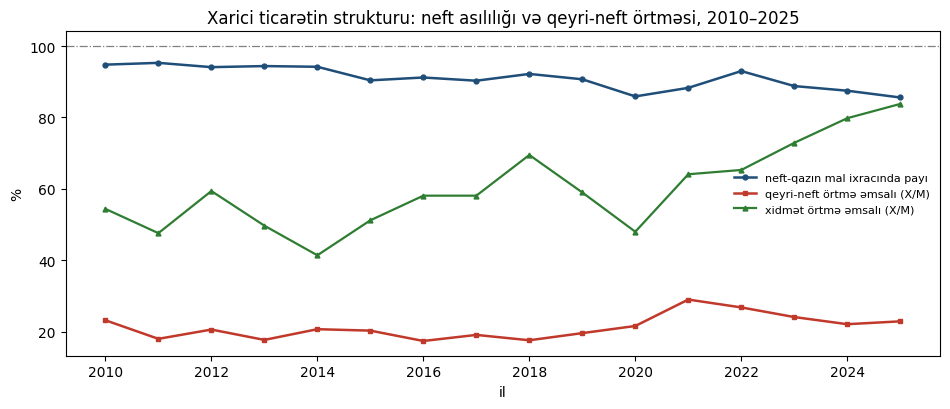

In [5]:
fig, ax = plt.subplots(figsize=(9.6, 4.2))
ax.plot(struct.index, struct["neft-qazın ixracda payı, %"], "-o", ms=3.5, lw=1.8,
        color="#1f4e79", label="neft-qazın mal ixracında payı")
ax.plot(struct.index, struct["qeyri-neft örtmə əmsalı, %"], "-s", ms=3.5, lw=1.8,
        color="#c0392b", label="qeyri-neft örtmə əmsalı (X/M)")
ax.plot(struct.index, struct["xidmət örtmə əmsalı, %"], "-^", ms=3.5, lw=1.6,
        color="#2e7d32", label="xidmət örtmə əmsalı (X/M)")
ax.axhline(100, color="grey", ls="-.", lw=0.9)
ax.set_title("Xarici ticarətin strukturu: neft asılılığı və qeyri-neft örtməsi, 2010–2025")
ax.set_ylabel("%"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8, loc="center right")
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR07_struktur.png"), dpi=140)
plt.show()

Mənzərə üç faktı ortaya qoyur. Birincisi, neft-qaz sektoru mal ixracının **85 %-dən çoxunu**
təşkil edir və bu pay 2010-cu ildən bəri praktiki olaraq dəyişməyib: 2010-cu ildə 94,8 %,
2025-ci ildə 85,6 %. İkincisi, qeyri-neft ixracı qeyri-neft idxalının yalnız **beşdə birini**
örtür (2025-ci ildə 22,9 %) — yəni qeyri-neft sektorunun xarici ticarəti struktur olaraq
kəsirlidir və bu kəsiri neft ixracının profisiti maliyyələşdirir. Üçüncüsü, xidmət balansı da
kəsirlidir, lakin örtmə əmsalı 2020-ci ilin 48 %-indən 2025-ci ildə 83,8 %-ə qalxıb — turizm və
tranzit gəlirlərinin bərpası bu yaxınlaşmanın əsas mənbəyidir. Bu üç fakt modelin qurulmasını
birbaşa yönləndirir: neft ixracı üçün qiymət mexanizmi, qeyri-neft axınları üçün isə tələb
mexanizmi əsas götürülür.

## 3. Model seçimi

### 3.1. Neft ixracı: dəyər = qiymət × həcm

Neft-qaz ixracının dəyəri bir mühasibat münasibətinin nəticəsidir: $X^{neft}_t = P^{ixrac}_t
\cdot V_t$, burada $P^{ixrac}$ neftin ixrac qiyməti (USD/barel), $V$ isə həmin qiymətlə ölçülmüş
ixrac həcmidir. Bu quruluşun üstünlüyü ondadır ki, iki hissə tamamilə fərqli mənbələrdən idarə
olunur və hər biri ayrıca yoxlanıla bilər:

$$\ln P^{ixrac}_t = \beta_0 + \beta_1 \ln P^{Brent}_t + u_t, \qquad
\Delta \ln V_t = \gamma_0 + \gamma_1 g^{neft}_t + \varepsilon_t$$

Birinci tənlik **səviyyələr üzrədir** və ona görə kointeqrasiya sınağı tələb edir: Azərbaycanın
ixrac etdiyi xam neft (Azeri Light) Brent markasına görə qiymətləndirildiyi üçün iki qiymət
arasında uzunmüddətli tarazlıq münasibətinin olması gözlənilir. Sınaq bu gözləntini təsdiqləyirsə,
tənlik xəta korreksiyası modeli (ECM) formasında qurulur. İkinci tənlik fərqlər səviyyəsindədir və
həcmi Nazirliyin hasilat planından (neft-qaz sektorunun real artım tempi, ekzogen fərziyyə) alır.

### 3.2. Qeyri-neft ixracı, idxal və xidmətlər

Qalan dörd axın **loq fərq** (artım tempi) formasında qurulur, çünki hamısı qeyri-stasionar
səviyyə sıralarıdır və n = 16 nümunədə səviyyə münasibətlərinin qiymətləndirilməsi üçün kifayət
qədər müşahidə yoxdur:

$$\Delta \ln X^{qeyri}_t = a_0 + a_1 g^{tərəfdaş}_t + a_2 \Delta \ln \text{REER}_t$$
$$\Delta \ln M^{qeyri}_t = b_0 + b_1 g^{absorbsiya}_t + b_2 \Delta \ln \text{REER}_t$$
$$\Delta \ln X^{xidmət}_t = c_0 + c_1 g^{tərəfdaş}_t + c_2 g^{qeyri-neft}_t, \qquad
\Delta \ln M^{xidmət}_t = d_0 + d_1 g^{qeyri-neft}_t$$

**Absorbsiya** daxili son tələbin real ölçüsüdür və FR1 nüvəsinin həll etdiyi istehlak və
investisiya yollarından qurulur: $A_t = C_t + I_t$ (İQİ ilə deflyasiya edilmiş), artım tempi isə
$\Delta \ln A_t$. Bu, idxalın iqtisadi cəhətdən düzgün sürücüsüdür — idxal ÜDM-in deyil, daxili
xərcləmənin funksiyasıdır.

**REER hər iki tənlikdə sınaqdan keçirilir, lakin avtomatik saxlanılmır.** İşarə iqtisadi cəhətdən
düzgün olmalıdır: real möhkəmlənmə ixracı azaltmalı ($a_2 < 0$), idxalı isə artırmalıdır
($b_2 > 0$). İşarə səhv çıxarsa, dəyişən tənlikdə saxlanılmır — hətta uyğunluğu yaxşılaşdırsa belə,
çünki bu halda əmsal rəqabət qabiliyyəti kanalını deyil, REER-in neft dövrü ilə birgə hərəkətini
ölçür.

### 3.3. Kiçik maddələr və balanslar

Neft-qaz sektorunun **idxalı** (əsasən layihə avadanlığı) mal idxalının təxminən altıda birini
təşkil edir və ayrıca davranış tənliyi ilə izah oluna bilmir; onun üçün bir neçə sadə qayda
sınaqdan keçirilir və seçim geriyə doğru sınağa buraxılır (Bölmə 6). **Balanslar** heç bir halda
qiymətləndirilmir: ticarət balansı = mal ixracı − mal idxalı, xidmətlər balansı = xidmət ixracı −
xidmət idxalı, hər il üçün eyniliklə hesablanır və yoxlanılır.

### 3.4. Effektiv məzənnənin proqnoz dəyəri — rejim fərziyyəsi

Proqnoz üfüqündə $\Delta \ln \text{REER} = 0$ götürülür. Bu, ekonometrik proqnoz deyil,
**rejim fərziyyəsidir** və FR10-un sənədləşdirdiyi məzənnə rejimi ilə, habelə FR9-un NEER üçün
qəbul etdiyi eyni qərarla ardıcıldır: manat 2017-ci ildən ABŞ dollarına 1,70 səviyyəsində
bağlıdır. Xarici blok faylının öz REER baza yolu (2026-cı ildə +8,1 %, sonrakı illərdə ildə
4,2–5,7 %) **qəbul edilmir**, çünki o, tərəfdaş valyutalarının son illərdəki sürətli
ucuzlaşmasının mexaniki davamıdır və paketin modelləşdirmədiyi xarici valyuta proqnozunu gizli
fərziyyə kimi daxil edərdi.

Lövbər ili **açıq şəkildə göstərilir**: REER-in 2026–2030 dəyəri `reer.loc[config.LAST_ACTUAL]`,
yəni 2025-ci ilin dəyəridir. Sıranın son mövcud müşahidəsinin avtomatik axtarılması (məsələn
`.dropna().index.max()` yazılışı) istifadə olunmur, çünki xarici blok faylı 2030-cu ilə qədər
öz baza dəyərlərini daşıyır və belə bir axtarış lövbəri səhvən 2030-cu ilə keçirərdi.

In [6]:
# --- absorbsiya: FR1 nüvəsinin istehlak və investisiya yollarından qurulur -----------------
A = outputs.read_assumptions()
for need in ("brent_usd", "oil_realg", "nonoil_realg", "g_cons_core", "g_inv_core",
             "partner_gdp_realg", "cpi_infl"):
    if need not in A:
        raise KeyError(f"'{need}' fərziyyə açarı yoxdur — yuxarı axın mərhələsi işləməyib")

cons = data_layer.actuals("final_consumption")        # son istehlak xərcləri, mln AZN
inv = data_layer.actuals("inv_total")                 # əsas kapitala cəmi investisiyalar, mln AZN
cpi_infl = data_layer.actuals("cpi_infl")

# İQİ bazis indeksi (2015 = 1,000) — rəsmi orta illik inflyasiyadan zəncirlə qurulur (FR9 ilə eyni qayda)
cpix = pd.Series(dtype=float); cpix.loc[2015] = 1.0
for y in range(2016, LA + 1):
    cpix.loc[y] = cpix.loc[y - 1] * (1 + cpi_infl.loc[y] / 100.0)
for y in range(2014, int(cpi_infl.index.min()), -1):
    cpix.loc[y] = cpix.loc[y + 1] / (1 + cpi_infl.loc[y + 1] / 100.0)
cpix = cpix.sort_index()

Cr = (cons / cpix.reindex(cons.index)).dropna()       # real istehlak (2015 qiymətləri ilə)
Ir = (inv / cpix.reindex(inv.index)).dropna()         # real investisiya
absorbsiya_hist = (np.log(Cr + Ir).diff() * 100.0)   # absorbsiya = son istehlak + investisiya
#   (real, 2015 qiymətləri ilə); göstərici onun REAL ARTIM TEMPİDİR, %

# üfüq: nüvənin həll etdiyi istehlak və investisiya artımı ildən-ilə çəkilərlə birləşdirilir
c_, i_ = float(Cr.loc[LA]), float(Ir.loc[LA])
# İki ayaq AYRICA da saxlanılır: icmalın B13 qeydi «investisiya göstəricisi də əlavə olunsun»
# deyir. İnvestisiya absorbsiyanın içindədir, lakin aqreqat AYNI elastikliyi məcbur edir; ayrıca
# sütunlar həmin məhdudiyyəti sınamağa imkan verir (aşağıda AYRI_C_I namizədi).
cons_hist = (np.log(Cr).diff() * 100.0)
inv_hist = (np.log(Ir).diff() * 100.0)
absorbsiya_fc, cons_fc, inv_fc = {}, {}, {}
for y in FY:   # 2026–2030 üfüqü — hər addımda əvvəlki ilin səviyyəsi növbəti ilin bazasıdır
    c2 = c_ * (1 + float(A["g_cons_core"].loc[y]) / 100.0)
    i2 = i_ * (1 + float(A["g_inv_core"].loc[y]) / 100.0)
    absorbsiya_fc[y] = (np.log(c2 + i2) - np.log(c_ + i_)) * 100.0
    cons_fc[y] = (np.log(c2) - np.log(c_)) * 100.0
    inv_fc[y] = (np.log(i2) - np.log(i_)) * 100.0
    c_, i_ = c2, i2

# --- sürücü cədvəli: faktiki hissə ≤2025, üfüq hissəsi fərziyyə dəstindən ------------------
REER_ANCHOR_YEAR = LA                                  # lövbər ili AÇIQ göstərilir (2025)
reer_anchor = float(reer_hist.loc[REER_ANCHOR_YEAR])
reer_path = pd.concat([reer_hist, pd.Series({y: reer_anchor for y in FY})])   # rejim: Δln REER = 0

# --- neft-qaz sektorunun investisiyası: `imp_goods_oil` sürücüsü namizədi (icmalın B14 qeydi) ---
# `imp_goods_oil` neftin/qazın İDXALI deyil — NEFT-QAZ SEKTORUNUN mal idxalıdır (8 vərəq,
# 2.4.1.13.-14.), yəni avadanlıq və qurğu səbətidir. Belə səbətin fiziki həcmi və vahid qiyməti
# heç bir mənbədə yoxdur, ona görə həcm × qiymət parçalanması bu sıraya tətbiq edilə bilmir.
# İqtisadi sürücü sektorun İNVESTİSİYASIDIR: FR06-nın nəşr etdiyi `inv_oil_g` diskdən oxunur
# (FR06 DAG-da bu mərhələdən əvvəldir).
_fl_inv = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
_oi = _fl_inv[(_fl_inv["series_code"] == "inv_oil_g") & (_fl_inv["source"] == "ours")]
oilinv_path = _oi.set_index("year")["value"].astype(float).sort_index()

DR = pd.DataFrame({
    "br": pd.concat([brent, A["brent_usd"]]),
    "oilg": pd.concat([oilg, A["oil_realg"]]),
    "nong": pd.concat([nong, A["nonoil_realg"]]),
    "partner": pd.concat([partner.loc[:LA], A["partner_gdp_realg"]]),
    "absorbsiya": pd.concat([absorbsiya_hist, pd.Series(absorbsiya_fc)]),
    "oilinv": oilinv_path,
    "cons_g": pd.concat([cons_hist, pd.Series(cons_fc)]),
    "inv_g": pd.concat([inv_hist, pd.Series(inv_fc)]),
    "reer": reer_path,
}).loc[:FY[-1]]
DR["dlbr"] = np.log(DR["br"]).diff() * 100.0           # Δln Brent, %
DR["dlreer"] = np.log(DR["reer"]).diff() * 100.0       # Δln REER, %

print(f"REER lövbəri: {REER_ANCHOR_YEAR} ili, dəyər = {reer_anchor:.3f} "
      f"(faylın öz 2030 dəyəri {float(ext['reer'].loc[2030]):.3f} — qəbul edilmir)")
print(DR.loc[2013:].round(2).to_string())

REER lövbəri: 2025 ili, dəyər = 1.249 (faylın öz 2030 dəyəri 1.671 — qəbul edilmir)
          br  oilg   nong  partner  absorbsiya  oilinv  cons_g  inv_g  reer   dlbr  dlreer
2013  108.56  1.00  10.18     2.41       10.86   29.08    9.76  12.35  1.04  -2.79    0.77
2014   98.97 -2.93   6.97     2.70        3.72   15.36    8.21  -2.70  1.08  -9.25    3.87
2015   52.32  1.18   0.73     2.96        1.26   15.16   10.14 -13.83  1.00 -63.74   -7.60
2016   43.64 -0.02  -4.48     2.91       -2.62    7.80    2.32 -12.85  0.73 -18.14  -30.92
2017   54.13 -5.03   2.84     3.94        0.17  -13.11    1.18  -2.14  0.75  21.54    1.76
2018   71.34  0.56   2.00     3.06        2.26  -30.92    4.59  -3.34  0.78  27.61    4.58
2019   64.30  0.43   3.96     2.33        5.44   -4.91    5.74   4.67  0.82 -10.39    4.87
2020   41.96 -6.34  -2.95    -4.97       -9.39   -0.38   -9.12 -10.07  0.88 -42.68    7.51
2021   70.86  2.02   7.13     8.61        0.16   -9.00    3.50  -8.90  0.95  52.40    6.88
2022  

## 4. Testlər

Sıraların inteqrasiya dərəcəsi ADF ilə, uzunmüddətli əlaqələr isə **yalnız `ek.eg_coint`**
(genişləndirilmiş Engle–Granger, MacKinnon kritik qiymətləri) ilə yoxlanılır. Qalıqlar üzərində
adi ADF p-qiyməti bu paketdə heç bir yerdə hesabat dəyəri kimi istifadə olunmur: qalıqlar
müşahidə deyil, qiymətləndirilmiş kointeqrasiya vektorunun nəticəsidir və adi Dickey–Fuller
cədvəlləri belə hallarda sıfır hipotezini həddindən artıq tez-tez rədd edir.

Gecikmə seçimi bu uzunluqda (n = 16–29) nümunələrdə açıq şəkildə məhdudlaşdırılır; əks halda
avtomatik seçim nümunənin böyük hissəsini gecikmələrə sərf edir.

In [7]:
lpe, lbr = np.log(pe), np.log(brent)
lxo = np.log(S["exp_goods_oil"])
V = (S["exp_goods_oil"] / pe).dropna().rename("V")     # dəyər/qiymət — ixrac həcminin ölçüsü

for t in [ek.adf(lpe, "ln P^ixrac (səviyyə), 1997–2025", maxlag=2),
          ek.adf(lbr.loc[1997:LA], "ln Brent (səviyyə), 1997–2025", maxlag=2),
          ek.adf(lxo, "ln X^neft (səviyyə), 2010–2025", maxlag=1),
          ek.adf(np.log(S["imp_goods_nonoil"]), "ln M^qeyri (səviyyə), 2010–2025", maxlag=1),
          ek.adf(DR.loc[2011:LA, "dlbr"], "Δln Brent, 2011–2025", maxlag=1)]:
    print(t)

ADF[ln P^ixrac (səviyyə), 1997–2025] stat=-2.881 p=0.0476 lag=2 n=26 kritik(1%: -3.71, 10%: -2.63, 5%: -2.98) → stasionar
ADF[ln Brent (səviyyə), 1997–2025] stat=-1.882 p=0.3404 lag=0 n=28 kritik(1%: -3.69, 10%: -2.63, 5%: -2.97) → vahid kök
ADF[ln X^neft (səviyyə), 2010–2025] stat=-2.631 p=0.0868 lag=1 n=14 kritik(1%: -4.01, 10%: -2.69, 5%: -3.10) → vahid kök
ADF[ln M^qeyri (səviyyə), 2010–2025] stat=-1.156 p=0.6924 lag=0 n=15 kritik(1%: -3.96, 10%: -2.68, 5%: -3.08) → vahid kök
ADF[Δln Brent, 2011–2025] stat=-3.615 p=0.0055 lag=1 n=13 kritik(1%: -4.07, 10%: -2.70, 5%: -3.13) → stasionar


In [8]:
# Kointeqrasiya YALNIZ eg_coint ilə — qalıqlara adi ADF tətbiq edilmir (§D5)
cr_price = ek.eg_coint(lpe, lbr.reindex(lpe.index).rename("lbr"),
                       name="ln P^ixrac ~ ln Brent", maxlag=2)
print(cr_price); print(cr_price.note_az)
print()
cr_val = ek.eg_coint(lxo, lbr.reindex(lxo.index).rename("lbr"),
                     name="ln X^neft ~ ln Brent", maxlag=1)
print(cr_val); print(cr_val.note_az)

EG-coint[ln P^ixrac ~ ln Brent] stat=-5.147 p=0.0001 n=29 k=1 kritik(1%: -4.33, 10%: -3.20, 5%: -3.56) → kointeqrasiya var
Kointeqrasiya (ln P^ixrac ~ ln Brent): EG statistikası -5.147, p = 0.000 (n = 29) → uzunmüddətli əlaqə təsdiqlənir, ECM tətbiq olunur.

EG-coint[ln X^neft ~ ln Brent] stat=-3.126 p=0.0833 n=16 k=1 kritik(1%: -4.78, 10%: -3.34, 5%: -3.77) → kointeqrasiya yoxdur
Kointeqrasiya (ln X^neft ~ ln Brent): EG statistikası -3.126, p = 0.083 (n = 16) → uzunmüddətli əlaqə təsdiqlənmir, tənlik fərqlər (Δ) səviyyəsində qurulur.


Nəticə iki səviyyə münasibətini aydın ayırır. **İxrac qiyməti ilə Brent arasında kointeqrasiya
möhkəm şəkildə təsdiqlənir** (EG statistikası −5,15, p = 0,0001, n = 29; 1 % kritik qiyməti
−4,33). Bu, iqtisadi cəhətdən gözlənilən nəticədir: Azeri Light Brent markasına görə
qiymətləndirilir və iki qiymət arasındakı fərq nəqliyyat və keyfiyyət marjası ilə məhdudlaşır.
Buna görə qiymət tənliyi **xəta korreksiyası modeli (ECM)** formasında qurulur.

**İxracın dəyəri ilə Brent arasında isə kointeqrasiya təsdiqlənmir** (EG statistikası −3,13,
p = 0,083, n = 16). Bu da gözləniləndir, çünki dəyər yalnız qiymətdən deyil, həm də azalan həcmdən
asılıdır; həcm sırası uzunmüddətli münasibətdə üçüncü dəyişən kimi iştirak edir və o olmadan
qalıq stasionar deyil. Ona görə dəyər səviyyədə deyil, **dekompozisiya yolu ilə** — qiymət və
həcmin hasili kimi — qurulur; alternativ olaraq birbaşa fərq tənliyi də saxlanılır və hər ikisi
Bölmə 6-da sınaqdan keçirilir.

## 5. Qiymətləndirmə

Bütün tənliklər HAC (Newey–West) standart xətaları ilə qiymətləndirilir; müşahidə sayı hər çıxışda
göstərilir və nümunə mərkəzləşdirilmiş qayda ilə (`config.LAST_ACTUAL`) 2025-ci ildə bitir.

In [9]:
def _eq_latex(res, labels, lhs):
    """Qiymətləndirilmiş tənliyi əmsallar və HAC standart xətaları ilə LaTeX-də göstərir."""
    body = ""
    for i, nm in enumerate(res.exog_names):
        b, se, lab = res.params[nm], res.se[nm], labels.get(nm, nm)
        sign = "-" if b < 0 else "+"
        term = f"{abs(b):.3f}" + ("" if lab == "" else r"\," + lab)
        pre = ("-" if sign == "-" else "") if i == 0 else f" {sign} "
        body += pre + r"\underset{(" + f"{se:.3f}" + r")}{" + term + "}"
    return lhs + " = " + body


LBL = {"const": "", "lbr": r"\ln P^{B}_t", "oilg": r"g^{neft}_t", "partner": r"g^{tərəfdaş}_t",
       "dlreer": r"\Delta\ln \mathrm{REER}_t", "dlbr": r"\Delta\ln P^{B}_t",
       "absorbsiya": r"g^{absorbsiya}_t", "nong": r"g^{qeyri-neft}_t", "covid": r"D^{20\text{-}21}_t",
       "ec_l1": r"u_{t-1}", "d_lbr": r"\Delta\ln P^{B}_t"}

### 5.1. Neftin ixrac qiyməti — xəta korreksiyası modeli

Kointeqrasiya təsdiqləndiyi üçün iki addımlı Engle–Granger proseduru tətbiq olunur: birinci
addımda səviyyələr üzrə uzunmüddətli əlaqə, ikinci addımda fərqlər üzrə korreksiya tənliyi
qiymətləndirilir.

In [10]:
ecm_price = ek.ardl_ecm(lpe, lbr.reindex(lpe.index).rename("lbr"),
                        name="ln P^ixrac ~ ln Brent", maxlags=1)
print()
print(ecm_price.note_az)
display(Math(_eq_latex(ecm_price.lr, LBL, r"\ln \hat{P}^{ixrac}_t")))
print(f"n = {ecm_price.lr.n},  nümunə = {ecm_price.lr.sample[0]}–{ecm_price.lr.sample[1]},  "
      f"düzəldilmiş R² = {ecm_price.lr.adj_r2:.3f},  reqressiyanın standart xətası = {ecm_price.lr.sigma:.4f}")
print("mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.")

[ECM] Kointeqrasiya (ln P^ixrac ~ ln Brent): EG statistikası -5.147, p = 0.000 (n = 29) → uzunmüddətli əlaqə təsdiqlənir, ECM tətbiq olunur.
[OLS+HAC] ln P^ixrac ~ ln Brent — uzunmüddətli: n=29, nümunə=1997–2025, R²=0.976, düzəldilmiş R²=0.975, s.x.=0.1113
[OLS+HAC] ln P^ixrac ~ ln Brent — ECM: n=28, nümunə=1998–2025, R²=0.951, düzəldilmiş R²=0.947, s.x.=0.0660

ECM (ln P^ixrac ~ ln Brent): korreksiya əmsalı α = -0.617 (t = -10.08, p = 0.000), yarım-ömür ≈ 0.7 il; uzunmüddətli əmsallar: lbr = 1.141.


<IPython.core.display.Math object>

n = 29,  nümunə = 1997–2025,  düzəldilmiş R² = 0.975,  reqressiyanın standart xətası = 0.1113
mötərizədə HAC (Newey–West, gecikmə 1) standart xətaları verilib.


Uzunmüddətli elastiklik **1,141** (HAC standart xətası 0,050, t = 23,0): Brent-in 10 %
bahalaşması Azərbaycanın ixrac qiymətini təxminən 11,4 % qaldırır. Vahiddən bir qədər böyük
olması qiymət səviyyəsinin loq şkalasında marjanın sabit deyil, nisbi olmasından irəli gəlir və
sıfırdan fərqli olsa da praktiki əhəmiyyət daşımır: son səkkiz ildə ixrac qiymətinin Brent-ə
nisbəti 0,93–1,04 aralığında qalıb. Korreksiya əmsalı **α = −0,617** (t = −10,1), yəni tarazlıqdan
kənarlaşmanın altıda beşdən çoxu bir il ərzində aradan qalxır; yarım-ömür 0,7 ildir. Bu, ticarət
olunan əmtəə qiyməti üçün gözlənilən sürətdir və proqnoz üfüqündə ixrac qiymətinin faktiki olaraq
Brent yolunu izləməsi deməkdir.

### 5.2. İxrac həcmi

Həcm sırası dəyərin ixrac qiymətinə bölünməsi ilə alınır ($V_t = X^{neft}_t / P^{ixrac}_t$) və
sürücüsü Nazirliyin hasilat planından gələn neft-qaz sektorunun real artım tempidir.

In [11]:
DV = pd.DataFrame({"dlV": np.log(V).diff() * 100.0, "oilg": DR["oilg"]}).loc[:LA].dropna()
res_vol = ek.ols_hac(DV["dlV"], DV[["oilg"]], maxlags=1, name="STRUKTUR: ixrac həcmi ~ hasilat planı")
print(res_vol)
display(Math(_eq_latex(res_vol, LBL, r"\Delta\ln \hat{V}_t")))

# KALİBRLƏNMİŞ variant: vahid elastiklik — həcm hasilat planını birbaşa izləyir
resid_cal = DV["dlV"] - DV["oilg"]
print(f"\nKalibrlənmiş variant (γ₁ = 1 tətbiq olunur): orta qalıq {resid_cal.mean():+.2f} %, "
      f"standart kənarlaşma {resid_cal.std():.2f} %")

[OLS+HAC] STRUKTUR: ixrac həcmi ~ hasilat planı: n=13, nümunə=2013–2025, R²=0.148, düzəldilmiş R²=0.071, s.x.=13.1772
OLS+HAC[STRUKTUR: ixrac həcmi ~ hasilat planı]  n=13  nümunə=2013–2025  HAC gecikmə=1
  R²=0.148  düzəldilmiş R²=0.071  reqressiyanın s.x.=13.1772
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.9992      3.4711     0.86    0.388
  oilg                  2.0838      0.5701     3.66    0.000


<IPython.core.display.Math object>


Kalibrlənmiş variant (γ₁ = 1 tətbiq olunur): orta qalıq +1.76 %, standart kənarlaşma 12.91 %


Qiymətləndirilmiş elastiklik **2,08** (HAC standart xətası 0,57, t = 3,66), lakin determinasiya
əmsalı cəmi 0,15-dir. Bu rəqəmi olduğu kimi qəbul etmək düzgün olmazdı: ixrac həcminin
sektorun öz istehsal həcmindən **iki dəfə sürətli** artması və ya azalması uzunmüddətli
perspektivdə mümkün deyil, çünki ixrac hasilatın özünün alt çoxluğudur. Elastikliyin vahiddən
böyük çıxması n = 13 nümunədə iki epizodun — 2022-ci ilin qeyri-adi yenidən ixrac artımının və
2023-cü ilin əks düzəlişinin — hökmranlığından irəli gəlir.

Ona görə **iki variant paralel saxlanılır**: qiymətləndirilmiş elastiklikli variant (struktur
şərh üçün) və vahid elastiklikli **kalibrlənmiş** variant ($\Delta \ln V_t = g^{neft}_t$, yəni
ixrac həcmi hasilat planını birbaşa izləyir). Hansının proqnozu daşıyacağı Bölmə 6-nın sınağına
buraxılır — bu, BUILD_CONTEXT §D5-in "identifikasiya oluna bilməyən parametr üçün açıq kalibrləmə
və həssaslıq qeydi" qaydasının tətbiqidir.

### 5.3. Qeyri-neft ixracı və REER sınağı

In [12]:
G = pd.DataFrame({
    "xn": np.log(S["exp_goods_nonoil"]).diff() * 100.0,
    "mn": np.log(S["imp_goods_nonoil"]).diff() * 100.0,
    "mo": np.log(S["imp_goods_oil"]).diff() * 100.0,
    "xs": np.log(S["exp_services"]).diff() * 100.0,
    "ms": np.log(S["imp_services"]).diff() * 100.0,
    "xo": np.log(S["exp_goods_oil"]).diff() * 100.0,
}).join(DR[["partner", "absorbsiya", "nong", "dlreer", "dlbr", "oilg"]]).loc[:LA]

sXN = G.loc[2011:LA]
res_xn = ek.ols_hac(sXN["xn"], sXN[["partner"]], maxlags=1,
                    name="STRUKTUR: qeyri-neft ixracı ~ tərəfdaş artımı")
print(res_xn)
res_xn_reer = ek.ols_hac(sXN["xn"], sXN[["partner", "dlreer"]], maxlags=1,
                         name="SINAQ: qeyri-neft ixracı ~ tərəfdaş + REER")
print(res_xn_reer)
res_xn_br = ek.ols_hac(sXN["xn"], sXN[["partner", "dlbr"]], maxlags=1,
                       name="STRUKTUR: qeyri-neft ixracı ~ tərəfdaş + Brent")
print(res_xn_br)
display(Math(_eq_latex(res_xn_br, LBL, r"\Delta\ln \hat{X}^{qeyri}_t")))

[OLS+HAC] STRUKTUR: qeyri-neft ixracı ~ tərəfdaş artımı: n=15, nümunə=2011–2025, R²=0.229, düzəldilmiş R²=0.170, s.x.=14.2747
OLS+HAC[STRUKTUR: qeyri-neft ixracı ~ tərəfdaş artımı]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.229  düzəldilmiş R²=0.170  reqressiyanın s.x.=14.2747
  dəyişən                əmsal    HAC s.x.        t        p
  const                -1.6405      5.0945    -0.32    0.747
  partner               2.7650      0.9622     2.87    0.004
[OLS+HAC] SINAQ: qeyri-neft ixracı ~ tərəfdaş + REER: n=15, nümunə=2011–2025, R²=0.606, düzəldilmiş R²=0.540, s.x.=10.6226
OLS+HAC[SINAQ: qeyri-neft ixracı ~ tərəfdaş + REER]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.606  düzəldilmiş R²=0.540  reqressiyanın s.x.=10.6226
  dəyişən                əmsal    HAC s.x.        t        p
  const                -2.6775      3.2446    -0.83    0.409
  partner               2.6233      0.5521     4.75    0.000
  dlreer                0.8899      0.1857     4.79    0.000
[OLS+HAC] STRUKTU

<IPython.core.display.Math object>

Tərəfdaş ölkələrin artımının əmsalı **2,77** (t = 2,87): xarici tələbin 1 faiz bəndlik
sürətlənməsi qeyri-neft ixracını təxminən 2,8 % artırır. Bu böyüklük kiçik və konsentrasiya olunmuş
ixrac səbəti üçün gözləniləndir.

**REER sınağının nəticəsi mənfidir və gizlədilmir.** Δln REER daxil edildikdə əmsal **+0,89**
(t = 4,79) çıxır, yəni real möhkəmlənmə ixracı **artırır** — bu, rəqabət qabiliyyəti kanalının
işarəsinin tam əksidir. Uyğunluq göstəricisi yaxşılaşsa da (düzəldilmiş R² 0,17-dən 0,54-ə qalxır),
əmsal iqtisadi cəhətdən şərh oluna bilməz: REER Azərbaycanda neft dövrü ilə birgə hərəkət edir
(neft bahalaşanda manat real möhkəmlənir, eyni vaxtda regional tələb və ixrac da artır), ona görə
əmsal rəqabət qabiliyyətini deyil, həmin ortaq dövrü ölçür.

Bu izahı yoxlamaq üçün REER-in yerinə birbaşa Δln Brent daxil edilir və nəticə izahı təsdiqləyir:
Brent-in əmsalı **+0,33** (t = 3,80) əhəmiyyətlidir, tərəfdaş artımının əmsalı isə 2,77-dən
**0,33-ə (t = 0,39)** düşərək əhəmiyyətini itirir. Yəni qeyri-neft ixracının illik dalğalanmasında
ölçülə bilən sürücü xarici tələbin özü deyil, neft dövrüdür — daxili sifarişlər, tikinti aktivliyi
və regional ticarət tərəfdaşlarının alıcılıq qabiliyyəti eyni mənbədən qidalanır. Bu, tələbin
"struktur" bölməsi üçün önəmli faktdır və proqnozda iki spesifikasiyanın da saxlanılmasını
əsaslandırır: sadə tərəfdaş tənliyi uzunmüddətli iqtisadi məntiqi, tərəfdaş + Brent tənliyi isə
nümunənin ölçdüyü faktiki dinamikanı təmsil edir. **REER variantı proqnoz mərhələsinə
buraxılmır** və yalnız tənlik kataloqunda sənədləşdirilir.

### 5.4. İdxal

In [13]:
res_mn = ek.ols_hac(sXN["mn"], sXN[["absorbsiya"]], maxlags=1,
                    name="STRUKTUR: qeyri-neft idxalı ~ absorbsiya")
print(res_mn)
res_mn_reer = ek.ols_hac(sXN["mn"], sXN[["absorbsiya", "dlreer"]], maxlags=1,
                         name="STRUKTUR: qeyri-neft idxalı ~ absorbsiya + REER")
print(res_mn_reer)
display(Math(_eq_latex(res_mn_reer, LBL, r"\Delta\ln \hat{M}^{qeyri}_t")))

[OLS+HAC] STRUKTUR: qeyri-neft idxalı ~ absorbsiya: n=15, nümunə=2011–2025, R²=0.222, düzəldilmiş R²=0.163, s.x.=14.9866
OLS+HAC[STRUKTUR: qeyri-neft idxalı ~ absorbsiya]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.222  düzəldilmiş R²=0.163  reqressiyanın s.x.=14.9866
  dəyişən                əmsal    HAC s.x.        t        p
  const                 2.0811      3.9743     0.52    0.601
  absorbsiya            1.3410      0.5721     2.34    0.019
[OLS+HAC] STRUKTUR: qeyri-neft idxalı ~ absorbsiya + REER: n=15, nümunə=2011–2025, R²=0.319, düzəldilmiş R²=0.205, s.x.=14.6014
OLS+HAC[STRUKTUR: qeyri-neft idxalı ~ absorbsiya + REER]  n=15  nümunə=2011–2025  HAC gecikmə=1
  R²=0.319  düzəldilmiş R²=0.205  reqressiyanın s.x.=14.6014
  dəyişən                əmsal    HAC s.x.        t        p
  const                 1.7413      3.7762     0.46    0.645
  absorbsiya            1.2043      0.6194     1.94    0.052
  dlreer                0.4754      0.1968     2.42    0.016


<IPython.core.display.Math object>

Absorbsiya elastikliyi **1,34** (t = 2,34): daxili son tələbin real 1 %-lik artımı qeyri-neft
idxalının dollar dəyərini təxminən 1,3 % qaldırır. Vahiddən böyük olması gözləniləndir, çünki
idxal səbəti investisiya mallarına və davamlı istehlak mallarına doğru meyllidir və bu qruplar
tələb dövründə daha güclü dalğalanır.

Burada **REER-in əmsalı iqtisadi cəhətdən düzgün işarədədir** (+0,48, t = 2,42): real möhkəmlənmə
idxal olunan malları daxili mallara nisbətən ucuzlaşdırır və idxalı artırır. Ona görə bu variant
qeyri-neft ixracından fərqli olaraq **saxlanılır** və sınağa buraxılır. Onun proqnoz üfüqündəki
təsiri neytraldır, çünki rejim fərziyyəsinə görə Δln REER = 0-dır; dəyişənin rolu yalnız tarixi
uyğunluğun və sabitin dəqiqləşdirilməsindədir.

### 5.5. Xidmətlər

In [14]:
sXS = G.loc[2013:LA]           # qeyri-neft artım sırası 2013-dən mövcuddur
res_xs = ek.ols_hac(sXS["xs"], sXS[["partner", "nong"]], maxlags=1,
                    name="STRUKTUR: xidmət ixracı ~ tərəfdaş + qeyri-neft")
print(res_xs)
res_xs_n = ek.ols_hac(sXS["xs"], sXS[["nong"]], maxlags=1,
                      name="STRUKTUR: xidmət ixracı ~ qeyri-neft")
print(res_xs_n)
res_ms = ek.ols_hac(sXS["ms"], sXS[["nong"]], maxlags=1,
                    name="STRUKTUR: xidmət idxalı ~ qeyri-neft")
print(res_ms)
display(Math(_eq_latex(res_ms, LBL, r"\Delta\ln \hat{M}^{xidmət}_t")))

# ROBUSTLİK: 2020–2021 pandemiya epizodu süni dəyişənlə nişanlanır (n = 13 — qayda §0-a görə zəif,
# ona görə nəticə yalnız robustlik kimi oxunur)
sR = sXS.copy(); sR["covid"] = 0.0; sR.loc[[2020, 2021], "covid"] = 1.0
res_ms_cov = ek.ols_hac(sR["ms"], sR[["nong", "covid"]], maxlags=1,
                        name="ROBUSTLİK: xidmət idxalı ~ qeyri-neft + pandemiya", verbose=False)
print(res_ms_cov)
sX = sR.drop(index=[2020, 2021])
res_ms_ex = ek.ols_hac(sX["ms"], sX[["nong"]], maxlags=1,
                       name="ROBUSTLİK: xidmət idxalı, 2020-21 istisna", verbose=False)
print(res_ms_ex)

[OLS+HAC] STRUKTUR: xidmət ixracı ~ tərəfdaş + qeyri-neft: n=13, nümunə=2013–2025, R²=0.709, düzəldilmiş R²=0.650, s.x.=11.9170
OLS+HAC[STRUKTUR: xidmət ixracı ~ tərəfdaş + qeyri-neft]  n=13  nümunə=2013–2025  HAC gecikmə=1
  R²=0.709  düzəldilmiş R²=0.650  reqressiyanın s.x.=11.9170
  dəyişən                əmsal    HAC s.x.        t        p
  const               -12.5858      3.1729    -3.97    0.000
  partner               5.1824      0.6598     7.85    0.000
  nong                  0.7891      0.7280     1.08    0.278
[OLS+HAC] STRUKTUR: xidmət ixracı ~ qeyri-neft: n=13, nümunə=2013–2025, R²=0.304, düzəldilmiş R²=0.241, s.x.=17.5579
OLS+HAC[STRUKTUR: xidmət ixracı ~ qeyri-neft]  n=13  nümunə=2013–2025  HAC gecikmə=1
  R²=0.304  düzəldilmiş R²=0.241  reqressiyanın s.x.=17.5579
  dəyişən                əmsal    HAC s.x.        t        p
  const                -4.2857      7.5364    -0.57    0.570
  nong                  2.5651      1.5473     1.66    0.097
[OLS+HAC] STRUKTUR: xidmə

<IPython.core.display.Math object>

OLS+HAC[ROBUSTLİK: xidmət idxalı ~ qeyri-neft + pandemiya]  n=13  nümunə=2013–2025  HAC gecikmə=1
  R²=0.702  düzəldilmiş R²=0.643  reqressiyanın s.x.=9.3803
  dəyişən                əmsal    HAC s.x.        t        p
  const                -8.3378      3.6964    -2.26    0.024
  nong                  3.0078      0.5113     5.88    0.000
  covid                -1.6875      4.0148    -0.42    0.674
OLS+HAC[ROBUSTLİK: xidmət idxalı, 2020-21 istisna]  n=11  nümunə=2013–2025  HAC gecikmə=1
  R²=0.671  düzəldilmiş R²=0.634  reqressiyanın s.x.=9.7180
  dəyişən                əmsal    HAC s.x.        t        p
  const                -9.1660      4.2872    -2.14    0.033
  nong                  3.2115      0.6965     4.61    0.000


Xidmət idxalının qeyri-neft artımına elastikliyi **3,03** (t = 6,36, düzəldilmiş R² = 0,67) —
bütün dəftərdəki ən möhkəm əlaqədir. Rəqəm böyükdür, lakin izahı sadədir: xidmət idxalının əsas
maddələri səyahət, nəqliyyat və işgüzar xidmətlərdir, hamısı da gəlirə görə yüksək elastikliyə
malikdir. Əlaqənin möhkəmliyi iki robustlik yoxlaması ilə təsdiqlənir: pandemiya süni dəyişəni
əlavə edildikdə əmsal 3,03-dən 3,01-ə dəyişir və süni dəyişənin özü əhəmiyyətsiz qalır
(−1,69, t = −0,42); 2020–2021 illəri nümunədən tamamilə çıxarıldıqda isə əmsal 3,21 olur
(t = 4,61). Yəni nəticə pandemiya epizodunun məhsulu deyil.

Xidmət **ixracı** üçün mənzərə daha zəifdir. Tərəfdaş artımı və qeyri-neft artımı birlikdə
düzəldilmiş R² = 0,65 verir, lakin qeyri-neft əmsalı əhəmiyyətli deyil (0,79, t = 1,08) və
tərəfdaş əmsalı (5,18) nümunə seçiminə həssasdır. Ona görə hər iki spesifikasiya sınağa
buraxılır və çəkiləri geriyə doğru sınaq müəyyən edir.

### 5.6. Neft-qaz sektorunun idxalı — kiçik maddə

Bu maddə üçün davranış tənliyi qurulmur. Aşağıda son üç ilin nisbətləri göstərilir; proqnoz
qaydasının seçimi Bölmə 6-nın sınağına buraxılır.

In [15]:
ratio = pd.DataFrame({
    "neft idxalı / qeyri-neft idxalı": S["imp_goods_oil"] / S["imp_goods_nonoil"],
    "neft idxalı / cəmi idxal": S["imp_goods_oil"] / S["imp_goods"],
}).round(4)
print(ratio.loc[2015:].to_string())
print(f"\nson üç ilin ortası (neft/qeyri-neft): {ratio.iloc[-3:, 0].mean():.4f}")
print(f"2010–2025 ortası:                      {ratio.iloc[:, 0].mean():.4f}")

      neft idxalı / qeyri-neft idxalı  neft idxalı / cəmi idxal
year                                                           
2015                           0.3260                    0.2459
2016                           0.3488                    0.2586
2017                           0.1745                    0.1486
2018                           0.1896                    0.1594
2019                           0.1990                    0.1660
2020                           0.2288                    0.1862
2021                           0.1848                    0.1559
2022                           0.2314                    0.1879
2023                           0.2103                    0.1737
2024                           0.1680                    0.1438
2025                           0.1665                    0.1428

son üç ilin ortası (neft/qeyri-neft): 0.1816
2010–2025 ortası:                      0.1941


## 6. Geriyə doğru sınaq

Sınaq genişlənən pəncərəli, bir addımlıq və nümunədən kənardır: hər sınaq ili üçün model YALNIZ
ondan əvvəlki illərin məlumatı ilə yenidən qiymətləndirilir. Etalon təsadüfi gəzişmədir (RW —
"növbəti il də bu ilki kimi olacaq"), ikinci etalon isə sürüşməli təsadüfi gəzişmədir (nümunə üzrə
orta illik loq artım tempi).

**Şərtlilik haqqında açıq qeyd.** Struktur modellər sınaqda cari ilin sürücü dəyərlərini (Brent,
hasilat planı, tərəfdaş artımı, absorbsiya) **məlum sayır**. Bu, onlara etalona nisbətən üstünlük
verən şərtdir və təsadüfən deyil, bilərəkdən seçilib: proqnoz mərhələsində həmin sürücülərin
yolları paketin yuxarı axınından (FR5, FR1) gəlir, yəni modellər məhz bu informasiya vəziyyətində
işləyəcək. Sınaq beləliklə "şərti proqnozun keyfiyyəti" sualına cavab verir. FR9-un təcrübəsi
göstərir ki, bu üstünlük özlüyündə qələbəni təmin etmir — cari il sürücüləri məlum olan Filips
tənliyi orada etalonu üstələməmişdi.

**Neftin ixrac qiyməti üçün ayrıca sətir yoxdur.** Bölmə 5.1-in xəta korreksiyası modeli
(`ecm_price`) aşağıdakı cədvəldə müstəqil bir sıra kimi görünmür, çünki onun proqnoz bacarığı
ayrılıqda deyil, `exp_goods_oil`-in (Bölmə 5.2) dekompozisiya modelləri (dəyər = qiymət × həcm)
vasitəsilə — qiymət tənliyinin bu modellərin bir komponenti olması üzündən — irsən sınanır.

In [16]:
def _fit(d, ycol, cols, minn):
    """Kiçik köməkçi: OLS uyğunlaşdırması, müşahidə sayı kifayət deyilsə None."""
    d = d[[ycol] + cols].dropna()
    if len(d) < minn:
        return None
    return sm.OLS(d[ycol], sm.add_constant(d[cols], has_constant="add")).fit()


def m_growth(drivers, minn=6):
    """STRUKTUR: loq artım tempi tənliyi, hər buraxılışda yenidən qiymətləndirilir."""
    def f(train, target_year):
        d = train.copy(); d["g"] = np.log(d["y"]).diff() * 100.0
        fit = _fit(d, "g", drivers, minn)
        if fit is None or target_year not in DR.index or DR.loc[target_year, drivers].isna().any():
            return np.nan
        g = fit.params["const"] + sum(fit.params[k] * DR.loc[target_year, k] for k in drivers)
        return float(train["y"].dropna().iloc[-1] * np.exp(g / 100.0))
    return f


def m_drift(train, target_year):
    """ETALON: sürüşməli təsadüfi gəzişmə — nümunə üzrə orta illik loq artım."""
    s = train["y"].dropna()
    if len(s) < 6:
        return np.nan
    return float(s.iloc[-1] * np.exp((np.log(s).diff() * 100.0).dropna().mean() / 100.0))


def m_decomp(calibrated=False):
    """STRUKTUR: dəyər = qiymət × həcm. calibrated=True olduqda həcm elastikliyi 1-ə bərabərdir."""
    def f(train, target_year):
        d = train.assign(lpe=np.log(train["pe"]), lbr=np.log(train["br"]))
        f1 = _fit(d, "lpe", ["lbr"], 8)
        if f1 is None or target_year not in DR.index:
            return np.nan
        if calibrated:
            dlV = float(DR.loc[target_year, "oilg"])
        else:
            dv = train.copy(); dv["dlV"] = np.log(dv["V"]).diff() * 100.0
            f2 = _fit(dv, "dlV", ["oilg"], 6)
            if f2 is None:
                return np.nan
            dlV = f2.params["const"] + f2.params["oilg"] * DR.loc[target_year, "oilg"]
        lp = f1.params["const"] + f1.params["lbr"] * np.log(DR.loc[target_year, "br"])
        return float(np.exp(lp) * train["V"].dropna().iloc[-1] * np.exp(dlV / 100.0))
    return f


def m_price_pt(train, target_year):
    """KALİBRLƏNMİŞ: dəyər Brent ilə mütənasib dəyişir, həcm sabit qalır."""
    # təlim pəncərəsinin SON ili (sıra üzrə lövbər deyil — pəncərə hər buraxılışda dəyişir)
    prev = int(train["y"].dropna().sort_index().index[-1])
    if target_year not in DR.index:
        return np.nan
    return float(train.loc[prev, "y"] * DR.loc[target_year, "br"] / DR.loc[prev, "br"])


def m_fixed_share(train, target_year, k=3):
    """KALİBRLƏNMİŞ: son üç ilin orta nisbəti qeyri-neft idxalına tətbiq olunur."""
    r = (train["y"] / train["mn_ref"]).dropna()
    if len(r) < 3 or target_year not in S["imp_goods_nonoil"].index:
        return np.nan
    return float(r.iloc[-k:].mean() * S["imp_goods_nonoil"].loc[target_year])

### 6.1. Xidmətlərin bölgüsü — altı komponent, hər iki istiqamətdə (xidmət bölgüsü)

İcmal xidmət ixracının və idxalının **adlandırılmış sahələr üzrə** verilməsini
istəyir. Tədiyyə Balansı vərəqi bu bölgünü 2010–2025 dövrü üçün artıq saxlayır və burada
modelə daxil edilir: neft-qaz / qeyri-neft-qaz kəsiyi (sətirlər 15/17 və 35/38), sonra
qeyri-neft blokunun içində **nəqliyyat** (18/39), **turizm** (22/43), **telekomunikasiya**
(28/49) və **digər işgüzar xidmətlər** (32/53). Beşinci komponent — *qalıq* — tikinti,
maliyyə və hökumət xidmətlərini, habelə yalnız 2022-ci ildən başlayan dörd alt sətri
(emal-təmir, royalti, sığorta, şəxsi-mədəni) birləşdirir; onlar ayrıca tənliklə
modelləşdirilmir, çünki 15 rüblük müşahidə elastiklik qiymətləndirməsi üçün kifayət deyil
(D5 nümunə intizamı).

Hər alt sətir üçün sürücü İQTİSADİ məzmuna görə seçilir və namizədlərin hamısı EYNİ
genişlənən pəncərəli sınaqda təsadüfi gəzişmə etalonu ilə yarışır: nəqliyyat ← xarici
ticarətin fiziki həcmi (ixrac + idxal dəyəri), turizm ← FR02-nin turizm sahəsi (turist
axınının vəkili), telekomunikasiya ← FR02-nin informasiya-rabitə sahəsi, digər işgüzar
xidmətlər ← qeyri-neft ixracı və neft-qaz sektorunun investisiyası, neft-qaz xidmətləri ←
neft-qaz sektorunun investisiyası və hasilat həcmi. Uduzan spesifikasiya silinmir —
kataloqda sınanmış kimi qalır (D4).


In [17]:
# ============ Xidmət bölgüsü: xidmət bölgüsünün məlumatı və mənbə eynilikləri ============
SERV_LEV = ["exp_serv_oil", "exp_serv_nonoil", "exp_serv_transport", "exp_serv_travel",
            "exp_serv_telecom", "exp_serv_business",
            "imp_serv_oil", "imp_serv_nonoil", "imp_serv_transport", "imp_serv_travel",
            "imp_serv_telecom", "imp_serv_business"]
for _c in SERV_LEV:
    S[_c] = data_layer.actuals(_c)

# QALIQ sətir: tikinti + maliyyə + hökumət + 2022-dən başlayan dörd alt sətir. Ayrıca tənlik
# qurulmur (nümunə qısadır), lakin cəm eyniliyi üçün AYRICA komponent kimi saxlanılır.
S["exp_serv_other"] = (S["exp_serv_nonoil"] - S["exp_serv_transport"] - S["exp_serv_travel"]
                       - S["exp_serv_telecom"] - S["exp_serv_business"])
S["imp_serv_other"] = (S["imp_serv_nonoil"] - S["imp_serv_transport"] - S["imp_serv_travel"]
                       - S["imp_serv_telecom"] - S["imp_serv_business"])

EXP_PARTS = ["exp_serv_oil", "exp_serv_transport", "exp_serv_travel", "exp_serv_telecom",
             "exp_serv_business", "exp_serv_other"]
IMP_PARTS = ["imp_serv_oil", "imp_serv_transport", "imp_serv_travel", "imp_serv_telecom",
             "imp_serv_business", "imp_serv_other"]
SERV_PARTS = EXP_PARTS + IMP_PARTS
SERV_PARENT = {c: ("exp_serv_nonoil" if c != "exp_serv_oil" else "exp_services")
               for c in EXP_PARTS}
SERV_PARENT.update({c: ("imp_serv_nonoil" if c != "imp_serv_oil" else "imp_services")
                    for c in IMP_PARTS})
# `exp_serv_oil` vərəqdə 2010–2014-cü illərdə SIFIRDIR (sətir yalnız 2015-dən doldurulub);
# səviyyə sırası olduğu kimi nəşr olunur, lakin loq-tənliklər 2015-dən qiymətləndirilir.
SERV_FIRST = {c: 2010 for c in SERV_PARTS}
SERV_FIRST["exp_serv_oil"] = 2015
SERV_MINTRAIN = {c: (5 if c == "exp_serv_oil" else 8) for c in SERV_PARTS}

v15 = validate.Verifier("FR07 — xidmət bölgüsünün mənbə eynilikləri (2010–2025)")
v15.identity("xidmət ixracı = neft-qaz + qeyri-neft-qaz", S["exp_services"],
             S["exp_serv_oil"] + S["exp_serv_nonoil"], tol=1e-6)
v15.identity("xidmət idxalı = neft-qaz + qeyri-neft-qaz", S["imp_services"],
             S["imp_serv_oil"] + S["imp_serv_nonoil"], tol=1e-6)
v15.identity("xidmət ixracı = altı komponentin cəmi", S["exp_services"],
             sum(S[c] for c in EXP_PARTS), tol=1e-6)
v15.identity("xidmət idxalı = altı komponentin cəmi", S["imp_services"],
             sum(S[c] for c in IMP_PARTS), tol=1e-6)
v15.assert_all()

serv_hist = pd.DataFrame({c: S[c] for c in EXP_PARTS + ["exp_services"]
                          + IMP_PARTS + ["imp_services"]})
print("Xidmət komponentləri, mln USD (idxal müsbət kəmiyyət kimi):")
print(serv_hist.round(0).to_string())


  YOXLAMA: FR07 — xidmət bölgüsünün mənbə eynilikləri (2010–2025)
  [PASS] eynilik: xidmət ixracı = neft-qaz + qeyri-neft-qaz
         16 il, maksimal fərq 4.547e-13
  [PASS] eynilik: xidmət idxalı = neft-qaz + qeyri-neft-qaz
         16 il, maksimal fərq 9.095e-13
  [PASS] eynilik: xidmət ixracı = altı komponentin cəmi
         16 il, maksimal fərq 9.095e-13
  [PASS] eynilik: xidmət idxalı = altı komponentin cəmi
         16 il, maksimal fərq 1.819e-12
--------------------------------------------------------------
  4/4 yoxlama uğurlu
Xidmət komponentləri, mln USD (idxal müsbət kəmiyyət kimi):
      exp_serv_oil  exp_serv_transport  exp_serv_travel  exp_serv_telecom  exp_serv_business  exp_serv_other  exp_services  imp_serv_oil  imp_serv_transport  imp_serv_travel  imp_serv_telecom  imp_serv_business  imp_serv_other  imp_services
year                                                                                                                                                         

In [18]:
# ============ Xidmət bölgüsü: alt sətirlərin sürücüləri və namizəd modelləri ============
_FL7 = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))


def _fr_path(fr, code_, kind="forecast"):
    """Yuxarı axın dəftərinin nəşr etdiyi yol (FR02 sahə artımları, FR06 investisiya)."""
    d = _FL7[(_FL7["fr"] == fr) & (_FL7["series_code"] == code_)
             & (_FL7["source"] == "ours") & (_FL7["kind"] == kind)]
    return d.set_index("year")["value"].astype(float).sort_index()


_inv_oil_h = data_layer.actuals("inv_oil")
_inv_oil_f = _fr_path("FR6", "inv_oil_nom")
_inv_oil = pd.concat([_inv_oil_h, _inv_oil_f]).sort_index()

# Sürücü cədvəli: FAKTİKİ hissə ≤2025 mənbədən, üfüq hissəsi yuxarı axının nəşrindən.
# Ticarət həcmi və qeyri-neft/neft ixrac yolları FR07-nin ÖZ mərkəzi yolundan gəlir; onlar
# 8-ci bölmədə (`central` qurulduqdan sonra) əlavə olunur — burada yalnız tarixi hissə var.
SDRV = pd.DataFrame({
    "ticaret": np.log(S["exp_goods"] + S["imp_goods"]).diff() * 100.0,
    "idxal_h": np.log(S["imp_goods"]).diff() * 100.0,
    "ixrac_qn": np.log(S["exp_goods_nonoil"]).diff() * 100.0,
    "ixrac_n": np.log(S["exp_goods_oil"]).diff() * 100.0,
    "turizm_s": pd.concat([data_layer.actuals("g_tourism"), _fr_path("FR2", "g_tourism")]),
    "ikt_s": pd.concat([data_layer.actuals("g_ict"), _fr_path("FR2", "g_ict")]),
    "neqliyyat_s": pd.concat([data_layer.actuals("g_transport"), _fr_path("FR2", "g_transport")]),
    "neft_inv": np.log(_inv_oil).diff() * 100.0,
    "nong": DR["nong"], "oilg": DR["oilg"], "partner": DR["partner"],
}).loc[:FY[-1]]


def s_growth(drivers, minn=6):
    """STRUKTUR: alt sətrin loq artımı sürücülərdən; hər buraxılışda yenidən qiymətləndirilir."""
    def f(train, target_year):
        d = train.copy()
        d["g"] = np.log(d["y"]).diff() * 100.0
        fit = _fit(d, "g", drivers, minn)
        if fit is None or target_year not in SDRV.index or SDRV.loc[target_year, drivers].isna().any():
            return np.nan
        g = fit.params["const"] + sum(fit.params[k] * SDRV.loc[target_year, k] for k in drivers)
        return float(train["y"].dropna().iloc[-1] * np.exp(g / 100.0))
    return f


# Üst göstəricinin TAM ÜFÜQLÜ yolu — yalnız `PAY` etalonu üçün. Proqnoz hissəsi üst
# göstəricinin ÖZ sürüşməli gəzişməsidir (kalibrlənmiş etalon; struktur tənlik deyil), belə ki
# alt sətirlərin cəmi ilə üst göstərici arasında dövrəvi asılılıq yaranmasın.
SPAR = {}
for _p in ["exp_serv_nonoil", "imp_serv_nonoil", "exp_services", "imp_services"]:
    _s = S[_p]
    _g = float((np.log(_s[_s > 0]).diff() * 100.0).dropna().mean())
    _cur, _out = float(_s.loc[LA]), {}
    for _y in FY:
        _cur = _cur * np.exp(_g / 100.0)
        _out[_y] = _cur
    SPAR[_p] = pd.concat([_s, pd.Series(_out)]).sort_index()


def s_share(parent, k=3):
    """KALİBRLƏNMİŞ etalon: son üç ilin orta payı üst göstəricinin öz yoluna tətbiq olunur."""
    def f(train, target_year):
        r = (train["y"] / train["par"]).dropna()
        if len(r) < k or target_year not in SPAR[parent].index:
            return np.nan
        return float(r.iloc[-k:].mean() * float(SPAR[parent].loc[target_year]))
    return f


SMENU = {
    "exp_serv_transport": {"TİCARƏT_HƏCMİ": s_growth(["ticaret"]),
                           "NƏQLİYYAT_SAHƏSİ": s_growth(["neqliyyat_s"]),
                           "TİCARƏT+TƏRƏFDAŞ": s_growth(["ticaret", "partner"]),
                           "PAY": s_share("exp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "exp_serv_travel": {"TURİZM_SAHƏSİ": s_growth(["turizm_s"]),
                        "TURİZM+TƏRƏFDAŞ": s_growth(["turizm_s", "partner"]),
                        "TƏRƏFDAŞ": s_growth(["partner"]),
                        "PAY": s_share("exp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "exp_serv_telecom": {"İKT_SAHƏSİ": s_growth(["ikt_s"]), "QEYRİNEFT": s_growth(["nong"]),
                         "İKT+QEYRİNEFT": s_growth(["ikt_s", "nong"]),
                         "PAY": s_share("exp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "exp_serv_business": {"QEYRİNEFT_İXRAC": s_growth(["ixrac_qn"]),
                          "QEYRİNEFT": s_growth(["nong"]),
                          "NEFT_İNVESTİSİYA": s_growth(["neft_inv"]),
                          "PAY": s_share("exp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "exp_serv_oil": {"NEFT_İNVESTİSİYA": s_growth(["neft_inv"], minn=5),
                     "NEFT_İXRAC": s_growth(["ixrac_n"], minn=5),
                     "NEFT_ARTIM": s_growth(["oilg"], minn=5),
                     "PAY": s_share("exp_services"), "SÜRÜŞMƏ": m_drift},
    "exp_serv_other": {"QEYRİNEFT": s_growth(["nong"]), "QEYRİNEFT_İXRAC": s_growth(["ixrac_qn"]),
                       "PAY": s_share("exp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_transport": {"TİCARƏT_HƏCMİ": s_growth(["ticaret"]),
                           "İDXAL_HƏCMİ": s_growth(["idxal_h"]),
                           "NƏQLİYYAT_SAHƏSİ": s_growth(["neqliyyat_s"]),
                           "PAY": s_share("imp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_travel": {"QEYRİNEFT": s_growth(["nong"]), "TURİZM_SAHƏSİ": s_growth(["turizm_s"]),
                        "PAY": s_share("imp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_telecom": {"İKT_SAHƏSİ": s_growth(["ikt_s"]), "QEYRİNEFT": s_growth(["nong"]),
                         "PAY": s_share("imp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_business": {"QEYRİNEFT": s_growth(["nong"]),
                          "NEFT_İNVESTİSİYA": s_growth(["neft_inv"]),
                          "NEFT_İNV+QEYRİNEFT": s_growth(["neft_inv", "nong"]),
                          "PAY": s_share("imp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_oil": {"NEFT_İNVESTİSİYA": s_growth(["neft_inv"]),
                     "NEFT_ARTIM": s_growth(["oilg"]),
                     "NEFT_İNV+ARTIM": s_growth(["neft_inv", "oilg"]),
                     "PAY": s_share("imp_services"), "SÜRÜŞMƏ": m_drift},
    "imp_serv_other": {"QEYRİNEFT": s_growth(["nong"]), "İDXAL_HƏCMİ": s_growth(["idxal_h"]),
                       "PAY": s_share("imp_serv_nonoil"), "SÜRÜŞMƏ": m_drift},
}


def _serv_frame(code_, upto=None):
    fr = SDRV.copy()
    fr["y"] = S[code_].loc[SERV_FIRST[code_]:]
    fr["par"] = S[SERV_PARENT[code_]]
    return fr if upto is None else fr.loc[:upto]


SBT = {c: ek.backtest(_serv_frame(c), SMENU[c], min_train=SERV_MINTRAIN[c],
                      series_code=c, min_points=4) for c in SERV_PARTS}

serv_skill = []
for c in SERV_PARTS:
    b = SBT[c]
    for m in sorted(b.rmse):
        serv_skill.append({"sıra": c, "model": m, "RMSE (mln USD)": b.rmse[m],
                           "RW-yə nisbətdə bacarıq, %": (None if b.rmse[m] is None or not b.rw_rmse
                                                         else (1 - b.rmse[m] / b.rw_rmse) * 100),
                           "ansambl çəkisi": b.weights.get(m)})
    serv_skill.append({"sıra": c, "model": "ANSAMBL", "RMSE (mln USD)": b.ensemble_rmse,
                       "RW-yə nisbətdə bacarıq, %": (None if b.skill is None else b.skill * 100),
                       "ansambl çəkisi": 1.0})
pd.DataFrame(serv_skill).set_index(["sıra", "model"]).round(2)


RMSE (mln USD)  RW-yə nisbətdə bacarıq, %  ansambl çəkisi
sıra           model                                                                      
exp_serv_oil   NEFT_ARTIM                349.35                      -8.96             NaN
               NEFT_İNVESTİSİYA          310.92                       3.03            0.51
               NEFT_İXRAC                381.20                     -18.89             NaN
               PAY                       467.41                     -45.77             NaN
               RW                        320.64                       0.00             NaN
...                                         ...                        ...             ...
imp_serv_other QEYRİNEFT                 212.29                      11.63            0.36
               RW                        240.22                       0.00             NaN
               SÜRÜŞMƏ                   215.43                      10.32            0.35
               İDXAL_HƏCMİ               232.05                       3.40            0.30
               ANSAMBL                   213.12                      11.28            1.00

[80 rows x 3 columns]

**Alt sətirlərin oxunuşu.** Turizm ixracı FR02-nin turizm sahəsi ilə çox möhkəm bağlıdır —
struktur model təsadüfi gəzişməni açıq şəkildə üstələyir və ansamblın əsas çəkisini alır;
bu, icmalın tələb etdiyi "sürücü iqtisadi məzmun daşımalıdır" şərtinin ən təmiz nümunəsidir.
Nəqliyyat ixracında isə ticarət həcmi etalonu üstələyə **bilmir** və çəkini sürüşməli
gəzişmə alır: sətir boru kəməri tranzitini və Orta Dəhliz yükünü birləşdirdiyi üçün onun
illik hərəkəti xarici ticarətin dəyər həcmindən daha çox marşrut qərarları ilə müəyyən
olunur. Bunu gizlətmirik — tənlik kataloqda **sınanmış və mərkəzi yola buraxılmamış** kimi
qalır (D4). Telekomunikasiya ixracı da etalonla daşınır: sətir kiçikdir (2025-ci ildə
130 mln USD) və illik hərəkəti sahə artımına deyil, ayrı-ayrı müqavilələrə bağlıdır.

İdxal tərəfində mənzərə daha güclüdür: nəqliyyat idxalı ticarət həcminə, turizm və digər
işgüzar xidmətlərin idxalı qeyri-neft sektorunun artımına, neft-qaz xidmət idxalı isə
neft-qaz sektorunun hasilat dövranına aydın reaksiya verir.


In [19]:
# ============ Xidmət bölgüsü: AŞAĞIDAN-YUXARI aqreqat — alt sətirlərin cəmi bir MODEL kimi ============
# Ansambl çəkiləri hər buraxılışda YENİDƏN hesablanır (yalnız ≤ t−1 məlumatı ilə): beləliklə
# aqreqat səviyyəsindəki müqayisədə gələcəyə baxış YOXDUR — nə əmsallarda, nə çəkilərdə.
def _serv_point(code_, train_end, target_year):
    b = ek.backtest(_serv_frame(code_, train_end), SMENU[code_],
                    min_train=SERV_MINTRAIN[code_], series_code=code_, min_points=3)
    train = _serv_frame(code_).loc[:train_end]
    if not b.weights:                      # pəncərə hələ qısadır → etalon (RW) daşıyır
        s_ = train["y"].dropna()
        return float(s_.iloc[-1]) if len(s_) else np.nan
    tot, wsum = 0.0, 0.0
    for m, w in b.weights.items():
        fn = SMENU[code_].get(m, ek._rw_forecast)
        try:
            p = fn(train, target_year)
        except Exception:
            p = np.nan
        if p is None or pd.isna(p):
            continue
        tot += w * float(p)
        wsum += w
    return np.nan if wsum <= 0 else tot / wsum


def m_bottomup(parts):
    def f(train, target_year):
        end = int(train.index.max())
        vals = [_serv_point(c, end, target_year) for c in parts]
        return np.nan if any(pd.isna(v) for v in vals) else float(sum(vals))
    return f


In [20]:
MODELS = {
    "exp_goods_oil": {"DEKOMPOZİSİYA": m_decomp(False), "DEKOMPOZİSİYA_KALİBR": m_decomp(True),
                      "BİRBAŞA": m_growth(["dlbr", "oilg"]), "QİYMƏT_ÖTÜRÜLMƏSİ": m_price_pt,
                      "SÜRÜŞMƏ": m_drift},
    "exp_goods_nonoil": {"TƏRƏFDAŞ": m_growth(["partner"]),
                         "TƏRƏFDAŞ+BRENT": m_growth(["partner", "dlbr"]), "SÜRÜŞMƏ": m_drift},
    "imp_goods_nonoil": {"ABSORBSİYA": m_growth(["absorbsiya"]),
                         "ABSORBSİYA+REER": m_growth(["absorbsiya", "dlreer"]),
                         # B13: istehlak və investisiya AYRICA — aqreqatın bərabər-elastiklik
                         # məhdudiyyəti sınaqda yoxlanılır, nəticə hansı olursa olsun nəşr olunur
                         "AYRI_C_I": m_growth(["cons_g", "inv_g", "dlreer"]),
                         "SÜRÜŞMƏ": m_drift},
    "imp_goods_oil": {"ABSORBSİYA": m_growth(["absorbsiya"]), "SABİT_PAY": m_fixed_share,
                      "SÜRÜŞMƏ": m_drift},
    # Xidmət bölgüsü: aqreqat tənliklər ilə AŞAĞIDAN-YUXARI cəm EYNİ pəncərədə yarışır (§8.1)
    "exp_services": {"TƏRƏFDAŞ": m_growth(["partner"]),
                     "TƏRƏFDAŞ+QEYRİNEFT": m_growth(["partner", "nong"]),
                     "QEYRİNEFT": m_growth(["nong"]), "SÜRÜŞMƏ": m_drift,
                     "AŞAĞIDAN_YUXARI": m_bottomup(EXP_PARTS)},
    "imp_services": {"QEYRİNEFT": m_growth(["nong"]), "ABSORBSİYA": m_growth(["absorbsiya"]),
                     "SÜRÜŞMƏ": m_drift, "AŞAĞIDAN_YUXARI": m_bottomup(IMP_PARTS)},
}

BT = {}
# --- B14: NEFT-QAZ SEKTORUNUN İDXALI üçün AYRICA yarış (öz ad fəzasında) ------------------
# `imp_goods_oil` neft/qazın idxalı DEYİL — sektorun mal idxalıdır (avadanlıq səbəti), ona görə
# həcm × qiymət parçalanması tətbiq edilmir; iqtisadi sürücü sektorun investisiyasıdır. Sürücünün
# tarixi qısa olduğu üçün ortaq pəncərə daralır və bu, MÖVCUD yarışın RW etalonunu dəyişərdi —
# paketin qaydası bunu qadağan edir. Ona görə müqayisə ayrıca sıra kodunda aparılır.
MODELS_OILIMP = {"NEFT_İNVESTİSİYA": m_growth(["oilinv"]),
                 "NEFT_İNV+HASİLAT": m_growth(["oilinv", "oilg"]),
                 "ABSORBSİYA": m_growth(["absorbsiya"])}
_fr_oi = DR.loc[:LA].copy(); _fr_oi["y"] = S["imp_goods_oil"]
BT_OILIMP = ek.backtest(_fr_oi, MODELS_OILIMP, min_train=6,
                        series_code="imp_goods_oil_neftinv", min_points=4)
print("B14 — neft-qaz sektorunun mal idxalı, sürücü namizədləri (ayrıca pəncərə):")
for _m in sorted(BT_OILIMP.rmse):
    _r = BT_OILIMP.rmse[_m]
    _sk = None if _r is None or not BT_OILIMP.rw_rmse else (1 - _r / BT_OILIMP.rw_rmse) * 100
    print(f"   {_m:20s} RMSE={_r if _r is None else round(_r,1)}  "
          f"bacarıq={'—' if _sk is None else format(_sk, '.1f') + ' %'}")
print(f"   RW RMSE={round(BT_OILIMP.rw_rmse, 1) if BT_OILIMP.rw_rmse else '—'}; "
      f"ansambl bacarığı={'—' if BT_OILIMP.skill is None else format(BT_OILIMP.skill * 100, '.1f') + ' %'}")

for code_ in CODES:
    frame = DR.loc[:LA].copy()
    frame["y"] = S[code_]
    if code_ == "exp_goods_oil":
        frame["pe"] = pe; frame["V"] = V
    if code_ == "imp_goods_oil":
        frame["mn_ref"] = S["imp_goods_nonoil"]
    # geriyə doğru sınaq: hər il üçün model yalnız ondan əvvəlki illərin məlumatı ilə qurulur
    BT[code_] = ek.backtest(frame, MODELS[code_], min_train=6, series_code=code_, min_points=4)

skill = []
for code_ in CODES:
    b = BT[code_]
    for m in sorted(b.rmse):
        skill.append({"sıra": code_, "model": m, "RMSE (mln USD)": b.rmse[m],
                      "RW-yə nisbətdə bacarıq, %": (None if b.rmse[m] is None or not b.rw_rmse
                                                    else (1 - b.rmse[m] / b.rw_rmse) * 100),
                      "80% zolağın əhatəsi": b.coverage80[m],
                      "ansambl çəkisi": b.weights.get(m)})
    skill.append({"sıra": code_, "model": "ANSAMBL", "RMSE (mln USD)": b.ensemble_rmse,
                  "RW-yə nisbətdə bacarıq, %": (None if b.skill is None else b.skill * 100),
                  "80% zolağın əhatəsi": None, "ansambl çəkisi": 1.0})
skill = pd.DataFrame(skill).set_index(["sıra", "model"]).round(3)
skill

B14 — neft-qaz sektorunun mal idxalı, sürücü namizədləri (ayrıca pəncərə):
   ABSORBSİYA           RMSE=427.7  bacarıq=-5.0 %
   NEFT_İNV+HASİLAT     RMSE=646.4  bacarıq=-58.7 %
   NEFT_İNVESTİSİYA     RMSE=448.2  bacarıq=-10.0 %
   RW                   RMSE=407.2  bacarıq=0.0 %
   RW RMSE=407.2; ansambl bacarığı=0.0 %


RMSE (mln USD)  RW-yə nisbətdə bacarıq, %  80% zolağın əhatəsi  ansambl çəkisi
sıra             model                                                                                               
exp_goods_oil    BİRBAŞA                     5427.386                     46.482                0.857           0.213
                 DEKOMPOZİSİYA               4898.855                     51.693                0.857           0.261
                 DEKOMPOZİSİYA_KALİBR        4595.955                     54.680                0.857           0.297
                 QİYMƏT_ÖTÜRÜLMƏSİ           5234.154                     48.387                0.857           0.229
                 RW                         10141.191                      0.000                0.714             NaN
                 SÜRÜŞMƏ                    10595.787                     -4.483                0.714             NaN
                 ANSAMBL                     4953.797                     51.152                  NaN           1.000
exp_goods_nonoil RW                           349.071                      0.000                0.889             NaN
                 SÜRÜŞMƏ                      311.012                     10.903                0.889           0.278
                 TƏRƏFDAŞ                     280.726                     19.579                0.778           0.341
                 TƏRƏFDAŞ+BRENT               265.430                     23.961                0.778           0.381
                 ANSAMBL                      263.617                     24.480                  NaN           1.000
imp_goods_oil    ABSORBSİYA                   644.179                    -27.543                0.778             NaN
                 RW                           505.068                      0.000                0.778           1.000
                 SABİT_PAY                    529.021                     -4.743                0.778             NaN
                 SÜRÜŞMƏ                      617.577                    -22.276                0.778             NaN
                 ANSAMBL                      505.068                      0.000                  NaN           1.000
imp_goods_nonoil ABSORBSİYA                  1212.371                     14.830                0.556           0.341
                 ABSORBSİYA+REER             1254.325                     11.883                0.889           0.319
                 AYRI_C_I                    2051.801                    -44.141                0.889             NaN
                 RW                          1423.472                      0.000                0.778             NaN
                 SÜRÜŞMƏ                     1215.175                     14.633                0.667           0.340
                 ANSAMBL                     1156.564                     18.750                  NaN           1.000
exp_services     AŞAĞIDAN_YUXARI              798.515                     33.983                0.714           0.357
                 QEYRİNEFT                   1000.229                     17.306                1.000           0.228
                 RW                          1209.555                      0.000                0.857             NaN
                 SÜRÜŞMƏ                     1121.482                      7.281                1.000           0.181
                 TƏRƏFDAŞ                    1547.418                    -27.933                0.857             NaN
                 TƏRƏFDAŞ+QEYRİNEFT           986.842                     18.413                0.714           0.234
                 ANSAMBL                      817.858                     32.384                  NaN           1.000
imp_services     ABSORBSİYA                   975.470                      7.266                0.857           0.127
                 AŞAĞIDAN_YUXARI              602.788                     42.695                0.714           0.333
                 QEYRİNEFT 

In [21]:
for code_ in CODES:
    print(BT[code_].note_az)
    print()

Geriyə doğru sınaq (exp_goods_oil): ümumi pəncərə 2019–2025 (7 il), RW RMSE = 10141.191, ansambl RMSE = 4953.797; bacarıq = 51%. Saxlanılan modellər: DEKOMPOZİSİYA (çəki 0.26), DEKOMPOZİSİYA_KALİBR (çəki 0.30), BİRBAŞA (çəki 0.21), QİYMƏT_ÖTÜRÜLMƏSİ (çəki 0.23).

Geriyə doğru sınaq (exp_goods_nonoil): ümumi pəncərə 2017–2025 (9 il), RW RMSE = 349.071, ansambl RMSE = 263.617; bacarıq = 24%. Saxlanılan modellər: TƏRƏFDAŞ (çəki 0.34), TƏRƏFDAŞ+BRENT (çəki 0.38), SÜRÜŞMƏ (çəki 0.28).

Geriyə doğru sınaq (imp_goods_oil): ümumi pəncərə 2017–2025 (9 il), RW RMSE = 505.068, ansambl RMSE = 505.068; bacarıq = 0%. Saxlanılan modellər: RW (çəki 1.00).

Geriyə doğru sınaq (imp_goods_nonoil): ümumi pəncərə 2017–2025 (9 il), RW RMSE = 1423.472, ansambl RMSE = 1156.564; bacarıq = 19%. Saxlanılan modellər: ABSORBSİYA (çəki 0.34), ABSORBSİYA+REER (çəki 0.32), SÜRÜŞMƏ (çəki 0.34).

Geriyə doğru sınaq (exp_services): ümumi pəncərə 2019–2025 (7 il), RW RMSE = 1209.555, ansambl RMSE = 817.858; bacarıq = 32%

**Sınağın oxunuşu.** Altı sıradan beşində struktur modellər etalonu aydın şəkildə üstələyir.

- **Neft-qaz ixracı** — ansambl bacarığı **+51 %** (sınaq pəncərəsi 2019–2025). Ən yaxşı ayrıca
  model kalibrlənmiş dekompozisiyadır (+55 %), yəni vahid həcm elastikliyi qiymətləndirilmiş
  2,08 elastikliyindən daha yaxşı proqnoz verir. Bu, Bölmə 5.2-nin qərarını təsdiqləyir. Diqqətəlayiq
  odur ki, ən sadə qayda — dəyərin Brent ilə mütənasib dəyişməsi — tək başına +48 % bacarıq verir:
  neft ixracının dəyərini idarə edən amil, əsasən, qiymətdir.
- **Qeyri-neft ixracı** — ansambl **+25 %**; tərəfdaş + Brent variantı ən yaxşı ayrıca modeldir (+24 %).
- **Qeyri-neft idxalı** — ansambl **+19 %**; absorbsiya tənliyi (+15 %) və sürüşməli etalon (+15 %)
  demək olar bərabərdir, ona görə hər ikisi ansamblda təxminən eyni çəki alır.
- **Xidmət ixracı** — ansambl **+26 %**; yalnız tərəfdaş artımı ilə qurulan variant etalonu
  üstələmir (−28 %), qeyri-neft artımı isə hər iki variantda faydalıdır.
- **Xidmət idxalı** — ansambl **+39 %**, qeyri-neft tənliyi tək başına **+49 %**. Bölmə 5.5-in
  möhkəm əlaqəsi burada da özünü göstərir.
- **Neft-qaz idxalı** — **heç bir model etalonu üstələmir**. Absorbsiya tənliyi −28 %, sabit pay
  qaydası −5 %, sürüşməli etalon −22 % verir. BUILD_CONTEXT §D4 qaydasına görə bu halda proqnozu
  etalon daşıyır: maddə 2025-ci ilin səviyyəsində saxlanılır. Sabit pay qaydası etalona yaxın
  olduğu üçün Bölmə 7.4-də həssaslıq kimi göstərilir.

Bu, ilk baxışdan gözlənilməz görünə bilər — kiçik maddə üçün ən sadə qayda qalib gəlir — lakin
səbəb sıranın öz təbiətindədir: neft-qaz idxalı layihə mərhələlərinə bağlı olduğu üçün kəskin,
lakin qanunauyğun olmayan sıçrayışlar edir (2015-ci ildə +51 %, 2017-ci ildə −55 %) və belə bir
sıra üçün makro sürücülər informasiya daşımır.

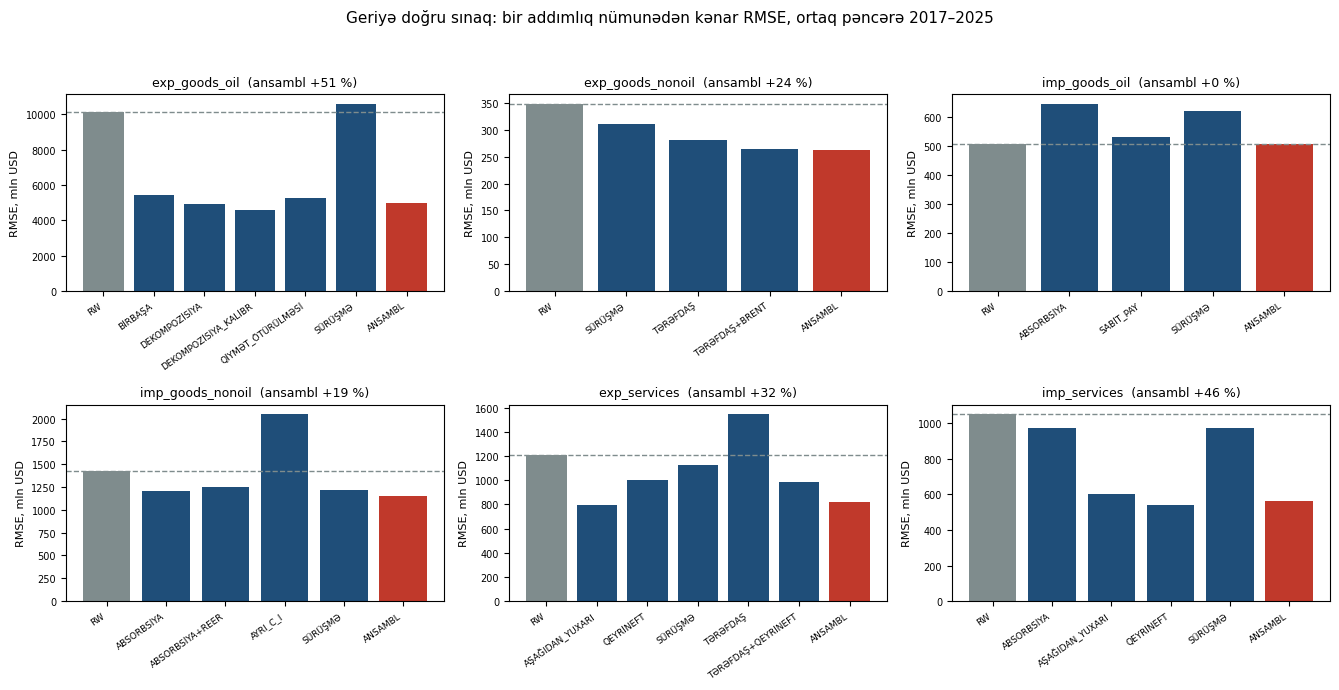

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7.0))
for ax, code_ in zip(axes.ravel(), CODES):
    b = BT[code_]
    names = [m for m in b.rmse if b.rmse[m] is not None]
    names = ["RW"] + [m for m in sorted(names) if m != "RW"]
    vals = [b.rmse[m] for m in names] + [b.ensemble_rmse]
    lbls = names + ["ANSAMBL"]
    colr = ["#7f8c8d"] + ["#1f4e79"] * (len(names) - 1) + ["#c0392b"]
    ax.bar(range(len(vals)), vals, color=colr)
    ax.axhline(b.rw_rmse, color="#7f8c8d", ls="--", lw=1.0)
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(lbls, rotation=35, ha="right", fontsize=6.5)
    sk = "" if b.skill is None else f"  (ansambl {b.skill*100:+.0f} %)"
    ax.set_title(f"{code_}{sk}", fontsize=9)
    ax.set_ylabel("RMSE, mln USD", fontsize=8)
    ax.tick_params(axis="y", labelsize=7)
fig.suptitle(f"Geriyə doğru sınaq: bir addımlıq nümunədən kənar RMSE, ortaq pəncərə "
             f"{BT['exp_goods_nonoil'].common_years[0]}–{LA}", fontsize=11)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(os.path.join(config.FIG, "FR07_geriye_sinaq.png"), dpi=140)
plt.show()

In [23]:
# B14-ün ayrıca yarışı da YAZILIR: rədd edilən namizəd kataloqdan/sınaqdan silinmir (D3).
bt_rows = pd.concat([BT[c].table for c in CODES]
                    + [SBT[c].table for c in SERV_PARTS]
                    + [BT_OILIMP.table], ignore_index=True)
outputs.write_backtest(bt_rows)
print(f"validation_backtest.csv-ə yazıldı: {len(bt_rows)} sətir, "
      f"{len(CODES) + len(SERV_PARTS) + 1} sıra (6 aqreqat + 12 xidmət alt sətri "
      f"+ `imp_goods_oil_neftinv` ayrıca yarışı)")

validation_backtest.csv-ə yazıldı: 746 sətir, 19 sıra (6 aqreqat + 12 xidmət alt sətri + `imp_goods_oil_neftinv` ayrıca yarışı)


## 7. Proqnoz 2026–2030

### 7.1. Sürücülər

Bütün sürücülər vahid fərziyyə dəstindən oxunur. Heç bir sürücü Nazirliyin Proqnoz sütunundan
gəlmir; yeganə istisna neft-qaz hasilatının real artım tempidir (`oil_realg`), o da FR5-də
**ekzogen fərziyyə** kimi sənədləşdirilib, çünki hasilat planı SOCAR-ın istehsal qərarıdır və
qanuni olaraq ekzogendir.

In [24]:
drv = DR.loc[FY, ["br", "dlbr", "oilg", "nong", "partner", "absorbsiya", "dlreer"]].copy()
drv.columns = ["Brent, USD/barel", "Δln Brent, %", "neft-qaz real artımı, %",
               "qeyri-neft real artımı, %", "tərəfdaş artımı, %", "absorbsiya artımı, %",
               "Δln REER, %"]
drv.round(2)

,"Brent, USD/barel","Δln Brent, %","neft-qaz real artımı, %","qeyri-neft real artımı, %","tərəfdaş artımı, %","absorbsiya artımı, %","Δln REER, %"
2026,68.98,-0.23,-1.16,5.31,2.46,3.37,0.0
2027,68.97,-0.01,-2.30,5.43,2.48,3.79,0.0
2028,69.40,0.62,-2.90,5.60,2.56,3.88,0.0
2029,69.46,0.09,3.17,5.63,2.50,3.93,0.0
2030,69.19,-0.39,-0.86,5.73,2.44,3.97,0.0


In [25]:
# --- hər sıra üçün bütün modellərin proqnoz yolları ----------------------------------------
def path_growth(code_, drivers, minn=6):
    d = DR.loc[:LA].copy(); d["y"] = S[code_]; d["g"] = np.log(d["y"]).diff() * 100.0
    fit = _fit(d, "g", drivers, minn)
    out, prev = {}, float(S[code_].loc[LA])
    for y in FY:
        g = fit.params["const"] + sum(fit.params[k] * DR.loc[y, k] for k in drivers)
        prev = prev * np.exp(g / 100.0)
        out[y] = prev
    return out


def path_drift(code_):
    s = S[code_]
    g = float((np.log(s).diff() * 100.0).dropna().mean())
    out, prev = {}, float(s.loc[LA])
    for y in FY:
        prev = prev * np.exp(g / 100.0)
        out[y] = prev
    return out


def path_rw(code_):
    return {y: float(S[code_].loc[LA]) for y in FY}


# neft ixracı: qiymət (ECM-in uzunmüddətli əlaqəsi) × həcm
lr_p = ecm_price.lr.params
pe_fc = pd.Series({y: float(np.exp(lr_p["const"] + lr_p["lbr"] * np.log(DR.loc[y, "br"])))
                   for y in FY})


def path_decomp(calibrated):
    out, Vc = {}, float(V.loc[LA])
    for y in FY:
        dlV = (float(DR.loc[y, "oilg"]) if calibrated
               else float(res_vol.params["const"] + res_vol.params["oilg"] * DR.loc[y, "oilg"]))
        Vc = Vc * np.exp(dlV / 100.0)
        out[y] = float(pe_fc.loc[y]) * Vc
    return out


path_pt, prev_, pb_ = {}, float(S["exp_goods_oil"].loc[LA]), float(DR.loc[LA, "br"])
for y in FY:
    prev_ = prev_ * float(DR.loc[y, "br"]) / pb_
    pb_ = float(DR.loc[y, "br"])
    path_pt[y] = prev_

PATHS = {
    "exp_goods_oil": {"DEKOMPOZİSİYA": path_decomp(False), "DEKOMPOZİSİYA_KALİBR": path_decomp(True),
                      "BİRBAŞA": path_growth("exp_goods_oil", ["dlbr", "oilg"]),
                      "QİYMƏT_ÖTÜRÜLMƏSİ": path_pt, "SÜRÜŞMƏ": path_drift("exp_goods_oil"),
                      "RW": path_rw("exp_goods_oil")},
    "exp_goods_nonoil": {"TƏRƏFDAŞ": path_growth("exp_goods_nonoil", ["partner"]),
                         "TƏRƏFDAŞ+BRENT": path_growth("exp_goods_nonoil", ["partner", "dlbr"]),
                         "SÜRÜŞMƏ": path_drift("exp_goods_nonoil"), "RW": path_rw("exp_goods_nonoil")},
    "imp_goods_nonoil": {"ABSORBSİYA": path_growth("imp_goods_nonoil", ["absorbsiya"]),
                         "ABSORBSİYA+REER": path_growth("imp_goods_nonoil", ["absorbsiya", "dlreer"]),
                         "AYRI_C_I": path_growth("imp_goods_nonoil", ["cons_g", "inv_g", "dlreer"]),
                         "SÜRÜŞMƏ": path_drift("imp_goods_nonoil"), "RW": path_rw("imp_goods_nonoil")},
    "imp_goods_oil": {"ABSORBSİYA": path_growth("imp_goods_oil", ["absorbsiya"]),
                      "SÜRÜŞMƏ": path_drift("imp_goods_oil"), "RW": path_rw("imp_goods_oil")},
    "exp_services": {"AŞAĞIDAN_YUXARI": None,     # §8-də alt sətirlərin cəmi ilə doldurulur
                     "TƏRƏFDAŞ": path_growth("exp_services", ["partner"]),
                     "TƏRƏFDAŞ+QEYRİNEFT": path_growth("exp_services", ["partner", "nong"]),
                     "QEYRİNEFT": path_growth("exp_services", ["nong"]),
                     "SÜRÜŞMƏ": path_drift("exp_services"), "RW": path_rw("exp_services")},
    "imp_services": {"AŞAĞIDAN_YUXARI": None,     # §8-də alt sətirlərin cəmi ilə doldurulur
                     "QEYRİNEFT": path_growth("imp_services", ["nong"]),
                     "ABSORBSİYA": path_growth("imp_services", ["absorbsiya"]),
                     "SÜRÜŞMƏ": path_drift("imp_services"), "RW": path_rw("imp_services")},
}

# Xidmət bölgüsü: aşağıdan-yuxarı yolu alt sətirlərin öz ansamblından yığılır (gələcəyə baxış yoxdur —
# əmsallar yalnız ≤2025 nümunəsindən, sürücülər isə yuxarı axının nəşr etdiyi yollardan gəlir).
def _bottomup_path(parts):
    out, cur = {}, {c: _serv_frame(c).loc[:LA].copy() for c in parts}
    for y in FY:
        tot = 0.0
        for c in parts:
            b, fn_map = SBT[c], SMENU[c]
            if not b.weights:
                p = float(ek._rw_forecast(cur[c], y))
            else:
                num = den = 0.0
                for m, w in b.weights.items():
                    fn = fn_map.get(m)
                    q = float(ek._rw_forecast(cur[c], y)) if fn is None else fn(cur[c], y)
                    if q is None or pd.isna(q):
                        continue
                    num += w * float(q); den += w
                p = float(ek._rw_forecast(cur[c], y)) if den <= 0 else num / den
            row = _serv_frame(c).loc[[y]].assign(y=p)
            cur[c] = pd.concat([cur[c], row])
            tot += p
        out[y] = tot
    return out


PATHS["exp_services"]["AŞAĞIDAN_YUXARI"] = _bottomup_path(EXP_PARTS)
PATHS["imp_services"]["AŞAĞIDAN_YUXARI"] = _bottomup_path(IMP_PARTS)

central = pd.DataFrame({c: BT[c].combine(PATHS[c]) for c in CODES})
central["exp_goods"] = central["exp_goods_oil"] + central["exp_goods_nonoil"]
central["imp_goods"] = central["imp_goods_oil"] + central["imp_goods_nonoil"]
central["trade_balance"] = central["exp_goods"] - central["imp_goods"]
central["services_balance"] = central["exp_services"] - central["imp_services"]
central.round(1)

,exp_goods_oil,exp_goods_nonoil,imp_goods_oil,imp_goods_nonoil,exp_services,imp_services,exp_goods,imp_goods,trade_balance,services_balance
2026,20054.2,3679.8,2526.4,16145.9,9372.7,11061.0,23734.1,18672.3,5061.8,-1688.3
2027,19853.7,3905.3,2526.4,17246.1,10241.3,12030.3,23759.0,19772.5,3986.5,-1789.1
2028,19686.2,4151.5,2526.4,18436.4,11193.9,13167.6,23837.7,20962.8,2874.9,-1973.7
2029,20555.9,4407.2,2526.4,19716.7,12211.5,13973.6,24963.1,22243.1,2720.0,-1762.1
2030,20551.6,4673.0,2526.4,21094.3,13311.9,15179.2,25224.6,23620.6,1603.9,-1867.2


### 7.2. Yelpik zolaqları

Zolaqlar iki mənbədən qurulur. Birincisi, **nümunədən kənar bir addımlıq xəta**: hər sıra üçün
ansamblın sınaqda ölçülmüş loq xətası (daxili qalıq dispersiyası deyil, faktiki proqnoz xətasının
ölçüsü). İkincisi, **parametr qeyri-müəyyənliyi**: aparıcı tənliyin HAC kovariasiya matrisindən
çoxölçülü normal paylanma ilə əmsal sapmaları çəkilir və gələcək dizayn matrisi vasitəsilə yola
ötürülür.

Zolaq **loq fəzada** qurulur və sonra səviyyəyə çevrilir; bu, mln USD ilə ölçülən müsbət
kəmiyyətlər üçün zəruridir, çünki səviyyə fəzasında simmetrik zolaq mənfi ixrac dəyərinə yol
verərdi. Üfüq boyu genişlənmə $\sqrt{h}$ qaydası ilədir: ticarət axınları səviyyə sıralarıdır və
xətalar yığılır.

Artım tempi formasında qurulan tənliklərdə əmsal sapmasının səviyyəyə təsiri də yığılır, ona görə
gələcək dizayn sətirləri **məcmu (kumulyativ)** şəkildə verilir. Neft ixracı blokunda isə qiymət
tənliyi birbaşa səviyyəni müəyyən etdiyi üçün dizayn sətri məcmu deyil, hər ilin öz sətridir.

**Məcmu göstəricilər və balanslar** üçün zolaqlar komponent zolaqlarının **konservativ
birləşdirilməsi** ilə alınır: cəm üçün aşağı sərhədlərin cəmi, balans üçün isə ixracın aşağı
sərhədi ilə idxalın yuxarı sərhədinin fərqi. Bu, komponent xətaları arasında tam korrelyasiya
fərz edir və ona görə həqiqi zolaqdan geniş olur; alternativ (müstəqillik) fərziyyəsi daha dar,
lakin daha az ehtiyatlı nəticə verərdi.

In [26]:
def ensemble_log_sigma(b):
    """Ansamblın bir addımlıq nümunədən kənar LOQ xətasının RMSE-si."""
    piv = b.table.pivot_table(index="vintage_year", columns="model", values="forecast")
    act = b.table.groupby("vintage_year")["actual"].first()
    e = pd.Series(0.0, index=piv.index)
    for m, w in b.weights.items():
        e = e + w * (np.log(piv[m]) - np.log(act))
    return float(np.sqrt((e ** 2).mean()))


# aparıcı tənlik və onun gələcək dizayn matrisi (parametr qeyri-müəyyənliyi üçün)
LEAD = {
    "exp_goods_oil": (ecm_price.lr, np.column_stack([np.ones(H), np.log(DR.loc[FY, "br"].values)]), False),
    "exp_goods_nonoil": (res_xn_br, np.column_stack([np.ones(H), DR.loc[FY, "partner"].values,
                                                     DR.loc[FY, "dlbr"].values]), True),
    "imp_goods_nonoil": (res_mn_reer, np.column_stack([np.ones(H), DR.loc[FY, "absorbsiya"].values,
                                                       DR.loc[FY, "dlreer"].values]), True),
    "imp_goods_oil": (None, None, False),
    "exp_services": (res_xs, np.column_stack([np.ones(H), DR.loc[FY, "partner"].values,
                                              DR.loc[FY, "nong"].values]), True),
    "imp_services": (res_ms, np.column_stack([np.ones(H), DR.loc[FY, "nong"].values]), True),
}

bands, sig_log = {}, {}
for k, code_ in enumerate(CODES):
    sig = ensemble_log_sigma(BT[code_])
    sig_log[code_] = sig
    res_, Xf, is_growth = LEAD[code_]
    cov = None if res_ is None else res_.cov_params.values
    if Xf is not None and is_growth:
        # artım tənliyində əmsal sapması səviyyədə yığılır; tənlik faizlə (Δln×100) qurulduğu üçün
        # dizayn sətirləri loq şkalasına gətirilir (÷100) — yol ln səviyyəsində simulyasiya olunur
        Xf = np.cumsum(Xf, axis=0) / 100.0
    lb_ = ek.fan(np.log(central.loc[FY, code_]), resid_sigma=sig, coef_cov=cov,
                 X_future=Xf, ndraw=8000, cumulative=True, seed=ek.SEED + k)
    bands[code_] = np.exp(lb_)

BAND = {c: bands[c] for c in CODES}
# konservativ birləşdirmə: cəmdə eyni istiqamətli sapma, balansda əks istiqamətli sapma
BAND["exp_goods"] = BAND["exp_goods_oil"] + BAND["exp_goods_nonoil"]
BAND["imp_goods"] = BAND["imp_goods_oil"] + BAND["imp_goods_nonoil"]
for nm, xk, mk_ in [("trade_balance", "exp_goods", "imp_goods"),
                    ("services_balance", "exp_services", "imp_services")]:
    BAND[nm] = pd.DataFrame({
        "lo80": BAND[xk]["lo80"] - BAND[mk_]["hi80"], "hi80": BAND[xk]["hi80"] - BAND[mk_]["lo80"],
        "lo50": BAND[xk]["lo50"] - BAND[mk_]["hi50"], "hi50": BAND[xk]["hi50"] - BAND[mk_]["lo50"]})

print("ansamblın loq xətası (σ, bir addımlıq):")
for c in CODES:
    print(f"  {c:<20} σ = {sig_log[c]:.3f}  →  ±{(np.exp(1.2816*sig_log[c])-1)*100:.0f} % (h = 1, 80 %)")

ansamblın loq xətası (σ, bir addımlıq):
  exp_goods_oil        σ = 0.163  →  ±23 % (h = 1, 80 %)
  exp_goods_nonoil     σ = 0.138  →  ±19 % (h = 1, 80 %)
  imp_goods_oil        σ = 0.265  →  ±40 % (h = 1, 80 %)
  imp_goods_nonoil     σ = 0.133  →  ±19 % (h = 1, 80 %)
  exp_services         σ = 0.159  →  ±23 % (h = 1, 80 %)
  imp_services         σ = 0.073  →  ±10 % (h = 1, 80 %)


### 8.1. Aqreqat tənlik, yoxsa alt sətirlərin cəmi? — birbaşa müqayisə

İki yanaşma EYNİ genişlənən pəncərədə, EYNİ etalona qarşı yarışdırılır: (i) əvvəlki mərhələdə qurulmuş
**aqreqat tənliklər** (xidmət ixracı ~ tərəfdaş artımı və/və ya qeyri-neft artımı) və
(ii) **AŞAĞIDAN-YUXARI** — altı alt sətrin öz ansamblının cəmi. Qalib qərarı ansambl
çəkiləri ilə verilir: hər ikisi etalonu üstələyirsə, hər ikisi tərs-RMSE² çəkisi ilə
mərkəzi yola daxil olur (paketin bütün digər sıralarında tətbiq olunan eyni qayda).

Nəşr olunan **cəm** bu ansamblın yoludur; alt sətirlər isə həmin cəmə uzlaşdırılır və
uzlaşdırma əmsalı ayrıca sıra kimi nəşr olunur (`exp_serv_uzlasma`, `imp_serv_uzlasma`) —
D4 qaydası: qalıq gizlədilmir, ölçülür və göstərilir.


In [27]:
# ============ Xidmət bölgüsü: alt sətirlərin proqnoz yolları və cəmə uzlaşdırılması ============
# Sürücü cədvəlinin ÜFÜQ hissəsi indi tamamlanır: ticarət həcmi və ixrac yolları FR07-nin
# öz mərkəzi yolundan gəlir (`central` yuxarıda quruldu), sahə artımları isə FR02/FR06-nın
# nəşrindən. `SDRV` qlobal ad olduğu üçün yuxarıdakı bağlamalar yenilənmiş cədvəli görür.
_xg_full = pd.concat([S["exp_goods"], central["exp_goods"]]).sort_index()
_mg_full = pd.concat([S["imp_goods"], central["imp_goods"]]).sort_index()
_xn_full = pd.concat([S["exp_goods_nonoil"], central["exp_goods_nonoil"]]).sort_index()
_xo_full = pd.concat([S["exp_goods_oil"], central["exp_goods_oil"]]).sort_index()
SDRV["ticaret"] = (np.log(_xg_full + _mg_full).diff() * 100.0).reindex(SDRV.index)
SDRV["idxal_h"] = (np.log(_mg_full).diff() * 100.0).reindex(SDRV.index)
SDRV["ixrac_qn"] = (np.log(_xn_full).diff() * 100.0).reindex(SDRV.index)
SDRV["ixrac_n"] = (np.log(_xo_full).diff() * 100.0).reindex(SDRV.index)
assert SDRV.loc[FY, ["ticaret", "idxal_h", "ixrac_qn", "ixrac_n", "turizm_s", "ikt_s",
                     "neqliyyat_s", "neft_inv", "nong", "oilg", "partner"]].notna().all().all(), \
    "Xidmət bölgüsü: üfüq üçün sürücü yolu tam deyil"


def _serv_path(code_):
    """Alt sətrin mərkəzi yolu: saxlanılan modellərin çəkili birləşməsi, 2026–2030."""
    b = SBT[code_]
    fr = _serv_frame(code_)
    paths = {}
    for m in b.weights:
        fn = SMENU[code_].get(m)
        out, cur = {}, fr.loc[:LA].copy()
        for y in FY:
            p = float(ek._rw_forecast(cur, y)) if fn is None else float(fn(cur, y))
            out[y] = p
            cur = pd.concat([cur, fr.loc[[y]].assign(y=p)])
        paths[m] = out
    return b.combine(paths)


SERV_CENTRAL_RAW = pd.DataFrame({c: _serv_path(c) for c in SERV_PARTS})

# UZLAŞDIRMA (D4): alt sətirlərin cəmi nəşr olunan cəmə bərabərləşdirilir; əmsal və qalıq
# ayrıca sıra kimi nəşr olunur. Aşağıdan-yuxarı model ansamblda böyük çəki alarsa əmsal
# vahidə yaxın olur — yəni uzlaşdırma "düzəliş" deyil, ölçüdür.
SERV_CENTRAL = SERV_CENTRAL_RAW.copy()
SERV_K = {}
for _side, _parts, _tot in [("exp", EXP_PARTS, "exp_services"), ("imp", IMP_PARTS, "imp_services")]:
    _sum = SERV_CENTRAL_RAW[_parts].sum(axis=1)
    _k = central.loc[FY, _tot] / _sum
    SERV_K[_side] = _k
    for c in _parts:
        SERV_CENTRAL[c] = SERV_CENTRAL_RAW[c] * _k

SERV_BAND = {}
for _i, c in enumerate(SERV_PARTS):
    _sig = ensemble_log_sigma(SBT[c])
    _lb = ek.fan(np.log(SERV_CENTRAL[c]), resid_sigma=_sig, ndraw=6000,
                 cumulative=True, seed=ek.SEED + 300 + _i)
    SERV_BAND[c] = np.exp(_lb)

print("Uzlaşdırma əmsalı (nəşr olunan cəm ÷ alt sətirlərin xam cəmi):")
print(pd.DataFrame({"ixrac": SERV_K["exp"], "idxal": SERV_K["imp"]}).round(4).to_string())
print("\nUzlaşdırma qalığı, mln USD:")
print(pd.DataFrame({
    "ixrac": central.loc[FY, "exp_services"] - SERV_CENTRAL_RAW[EXP_PARTS].sum(axis=1),
    "idxal": central.loc[FY, "imp_services"] - SERV_CENTRAL_RAW[IMP_PARTS].sum(axis=1),
}).round(1).to_string())
print("\nAlt sətirlərin mərkəzi yolu (uzlaşdırılmış), mln USD:")
print(SERV_CENTRAL.round(1).to_string())


Uzlaşdırma əmsalı (nəşr olunan cəm ÷ alt sətirlərin xam cəmi):
       ixrac   idxal
2026  0.9821  0.9991
2027  0.9618  0.9848
2028  0.9413  0.9640
2029  0.9186  1.0004
2030  0.8946  0.9939

Uzlaşdırma qalığı, mln USD:
       ixrac  idxal
2026  -170.8   -9.9
2027  -406.8 -185.4
2028  -698.7 -492.3
2029 -1082.3    5.1
2030 -1568.1  -93.7

Alt sətirlərin mərkəzi yolu (uzlaşdırılmış), mln USD:
      exp_serv_oil  exp_serv_transport  exp_serv_travel  exp_serv_telecom  exp_serv_business  exp_serv_other  imp_serv_oil  imp_serv_transport  imp_serv_travel  imp_serv_telecom  imp_serv_business  imp_serv_other
2026        1768.7              2145.0           2336.6             128.0             2593.9           400.5        3369.5              1830.0           1713.9             294.8             2378.4          1474.4
2027        1917.6              2267.2           2672.3             125.3             2833.5           425.4        3657.7              1917.0           1850.8             327.2    

Xidmət strukturu — komponent payları:
                              pay 2010, %  pay 2019, %  pay 2025, %  pay 2030, %  2025, mln USD  2030, mln USD
istiqamət komponent                                                                                           
ixrac     exp_serv_oil                0.0          5.3         19.0         18.2         1630.9         2426.8
          exp_serv_transport         31.2         24.1         23.5         19.9         2023.6         2651.6
          exp_serv_travel            30.1         47.6         23.1         29.5         1983.9         3927.0
          exp_serv_telecom            3.7          1.6          1.5          0.9          130.3          116.6
          exp_serv_business          23.0         19.4         27.3         27.7         2343.5         3685.5
          exp_serv_other             12.1          2.0          5.6          3.8          483.4          504.6
idxal     imp_serv_oil               32.7         32.0         31.8       

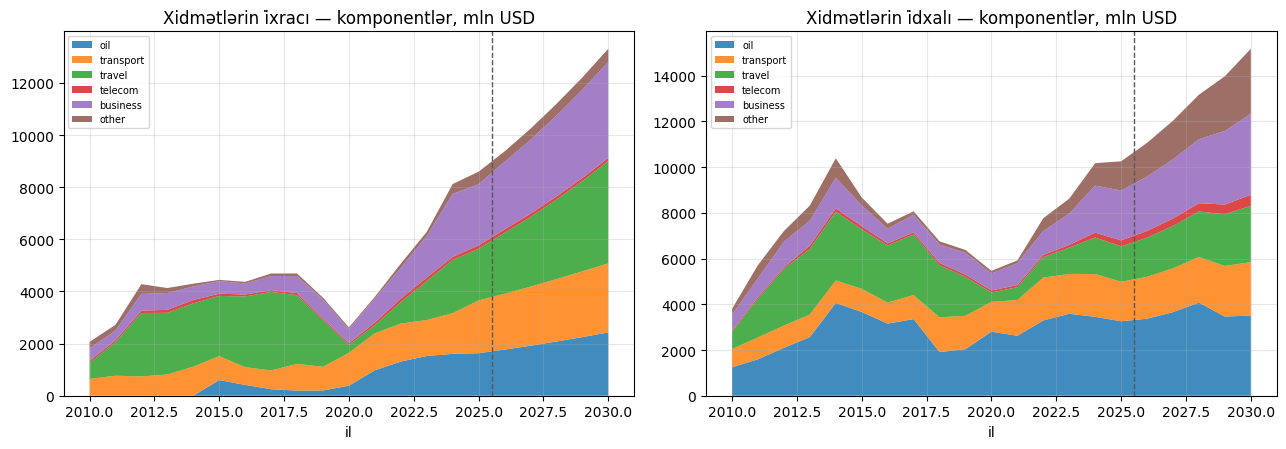

In [28]:
# ============ Xidmət bölgüsü: xidmət strukturunun cədvəli və qrafiki ============
_struct_rows = []
for _lab, _parts, _tot in [("ixrac", EXP_PARTS, "exp_services"), ("idxal", IMP_PARTS, "imp_services")]:
    _hist = pd.DataFrame({c: S[c] for c in _parts})
    _fc = SERV_CENTRAL[_parts]
    _full = pd.concat([_hist, _fc])
    _sh = _full.div(_full.sum(axis=1), axis=0) * 100.0
    for c in _parts:
        _struct_rows.append({"istiqamət": _lab, "komponent": c,
                             "pay 2010, %": _sh.loc[2010, c], "pay 2019, %": _sh.loc[2019, c],
                             "pay 2025, %": _sh.loc[LA, c], "pay 2030, %": _sh.loc[FY[-1], c],
                             "2025, mln USD": _full.loc[LA, c], "2030, mln USD": _full.loc[FY[-1], c]})
serv_struct = pd.DataFrame(_struct_rows).set_index(["istiqamət", "komponent"]).round(1)
print("Xidmət strukturu — komponent payları:")
print(serv_struct.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))
for ax, (_lab, _parts) in zip(axes, [("İxrac", EXP_PARTS), ("İdxal", IMP_PARTS)]):
    _full = pd.concat([pd.DataFrame({c: S[c] for c in _parts}), SERV_CENTRAL[_parts]])
    ax.stackplot(_full.index, [_full[c].values for c in _parts],
                 labels=[c.split("_", 2)[-1] for c in _parts], alpha=0.85)
    ax.axvline(LA + 0.5, color="0.35", lw=1.0, ls="--")
    ax.set_title(f"Xidmətlərin {_lab.lower()}ı — komponentlər, mln USD")
    ax.set_xlabel("il"); ax.legend(fontsize=7, loc="upper left")
    ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()


**Strukturun oxunuşu.** İxracda turizmin payı 2019-cu ilə qədər artmış, pandemiyada
çökmüş və 2025-ci ilə qədər tam bərpa olunmamışdır; onun yerini **digər işgüzar
xidmətlər** tutmuşdur — 2010-cu ildə ixracın təxminən dörddə biri, 2025-ci ildə isə
ən böyük tək komponent. Neft-qaz xidmət ixracı sətri yalnız 2015-ci ildən doldurulub və
2021-ci ildən sürətlə artır. İdxalda isə struktur daha sabitdir: neft-qaz sektorunun
xidmət idxalı bütün dövr boyu ən böyük tək maddədir və onun hərəkəti sektorun investisiya
dövranını izləyir.


In [29]:
tbl = central[CODES + AGG].round(1).copy()
tbl["ticarət balansı 80% aşağı"] = BAND["trade_balance"]["lo80"].round(1)
tbl["ticarət balansı 80% yuxarı"] = BAND["trade_balance"]["hi80"].round(1)
tbl

,exp_goods_oil,exp_goods_nonoil,imp_goods_oil,imp_goods_nonoil,exp_services,imp_services,exp_goods,imp_goods,trade_balance,services_balance,ticarət balansı 80% aşağı,ticarət balansı 80% yuxarı
2026,20054.2,3679.8,2526.4,16145.9,9372.7,11061.0,23734.1,18672.3,5061.8,-1688.3,-3514.0,13810.9
2027,19853.7,3905.3,2526.4,17246.1,10241.3,12030.3,23759.0,19772.5,3986.5,-1789.1,-8972.6,16824.1
2028,19686.2,4151.5,2526.4,18436.4,11193.9,13167.6,23837.7,20962.8,2874.9,-1973.7,-13787.9,19391.0
2029,20555.9,4407.2,2526.4,19716.7,12211.5,13973.6,24963.1,22243.1,2720.0,-1762.1,-18052.3,23008.4
2030,20551.6,4673.0,2526.4,21094.3,13311.9,15179.2,25224.6,23620.6,1603.9,-1867.2,-23245.7,25644.0


### 7.3. Şablon-nümunə ssenarisi ilə müqayisə

In [30]:
MB = pd.DataFrame({c: data_layer.ministry_baseline(c) for c in CODES + AGG})
cmp_tbl = pd.DataFrame({
    "bizim, 2026": central.loc[FY[0]], "şablon, 2026": MB.loc[FY[0]],
    "bizim, 2030": central.loc[FY[-1]], "şablon, 2030": MB.loc[FY[-1]],
})
cmp_tbl["fərq 2030, %"] = ((cmp_tbl["bizim, 2030"] / cmp_tbl["şablon, 2030"] - 1) * 100)
display(cmp_tbl.round(1))

# Nazirliyin neft ixracı dəyərindən çıxan gizli ixrac qiyməti: dəyər ÷ hasilat planına uyğun həcm
Vp, imp_price = float(V.loc[LA]), {}
for y in FY:
    Vp = Vp * np.exp(float(DR.loc[y, "oilg"]) / 100.0)
    imp_price[y] = float(MB.loc[y, "exp_goods_oil"]) / Vp
gizli = pd.DataFrame({
    "Nazirliyin X_neft, mln USD": MB["exp_goods_oil"],
    "hasilat planına uyğun həcm": pd.Series({y: float(V.loc[LA]) * np.exp(
        sum(float(DR.loc[k, "oilg"]) for k in FY if k <= y) / 100.0) for y in FY}),
    "gizli ixrac qiyməti, USD/barel": pd.Series(imp_price),
    "bizim ixrac qiyməti, USD/barel": pe_fc,
}).round(1)
gizli

,"bizim, 2026","şablon, 2026","bizim, 2030","şablon, 2030","fərq 2030, %"
exp_goods_oil,20054.2,16533.4,20551.6,14920.6,37.7
exp_goods_nonoil,3679.8,3834.1,4673.0,5473.3,-14.6
imp_goods_oil,2526.4,2547.5,2526.4,1371.5,84.2
imp_goods_nonoil,16145.9,14706.9,21094.3,18073.7,16.7
exp_services,9372.7,9257.3,13311.9,11046.1,20.5
imp_services,11061.0,10055.6,15179.2,10314.4,47.2
exp_goods,23734.1,20367.5,25224.6,20393.9,23.7
imp_goods,18672.3,17254.3,23620.6,19445.2,21.5
trade_balance,5061.8,3113.1,1603.9,948.7,69.1
services_balance,-1688.3,-798.3,-1867.2,731.7,-355.2


,"Nazirliyin X_neft, mln USD",hasilat planına uyğun həcm,"gizli ixrac qiyməti, USD/barel","bizim ixrac qiyməti, USD/barel"
2026,16533.4,291.5,56.7,66.6
2027,15297.1,284.8,53.7,66.6
2028,14564.3,276.7,52.6,67.0
2029,15005.2,285.6,52.5,67.1
2030,14920.6,283.1,52.7,66.8


Fərqin mənbəyi bir yerdə cəmlənir və onu gizlətməyin mənası yoxdur. Şablon-nümunə ssenarisində
neft-qaz ixracı 2026-cı ildə 16 533 mln USD, 2030-cu ildə isə 14 921 mln USD götürülür — yəni
2025-ci ilin 20 605 mln USD səviyyəsindən bir il ərzində 20 % enmə. Yuxarıdakı cədvəl bu dəyərin
hasilat planına uyğun həcmə bölünməsi ilə hansı ixrac qiymətinə uyğun gəldiyini göstərir: 2026-cı
il üçün təxminən 57 USD/barel, 2030-cu il üçün isə 52 USD/barel. Bu, həm statutar şablonun öz
sabit 65 USD/barel fərziyyəsindən, həm də bu dəftərin qiymət tənliyinin verdiyi 66,6–67,1
USD/barel-dən aşağıdır. Beləliklə fərq metodoloji deyil, fərziyyə fərqidir: iki proqnoz eyni həcm
planını götürür, lakin fərqli qiymət lövbərindən çıxış edir və Nazirliyin lövbəri öz şablonundakı
65 USD fərziyyəsi ilə də tam uzlaşmır.

İkinci fərq idxal tərəfindədir. Qeyri-neft idxalı bizim yolda 2030-cu ilə qədər 17 % yüksəkdir,
çünki o, FR1 nüvəsinin həll etdiyi absorbsiya artımından (ildə 3,4–4,0 %) qidalanır; nisbətə
çevirdikdə bu, idxalın ÜDM-ə nisbətinin 2025-ci ildəki 20 % səviyyəsində qalması deməkdir, yəni
idxal payının artması deyil, sabit qalmasıdır. Nazirliyin yolu isə həmin nisbətin tədricən
azalmasını nəzərdə tutur.

Nəticə etibarilə **ticarət balansı bizim proqnozda daha yüksəkdir** (2030-cu ildə 1 604 mln USD,
Nazirliyin ssenarisində 949 mln USD), lakin **istiqamət eynidir**: profisit üfüq boyu aşağı düşür.
Hər iki proqnozun ortaq mesajı budur ki, neft-qaz profisiti sabit qiymət və azalan hasilat
şəraitində qeyri-neft kəsirinin artımını getdikcə daha çətinliklə örtür.

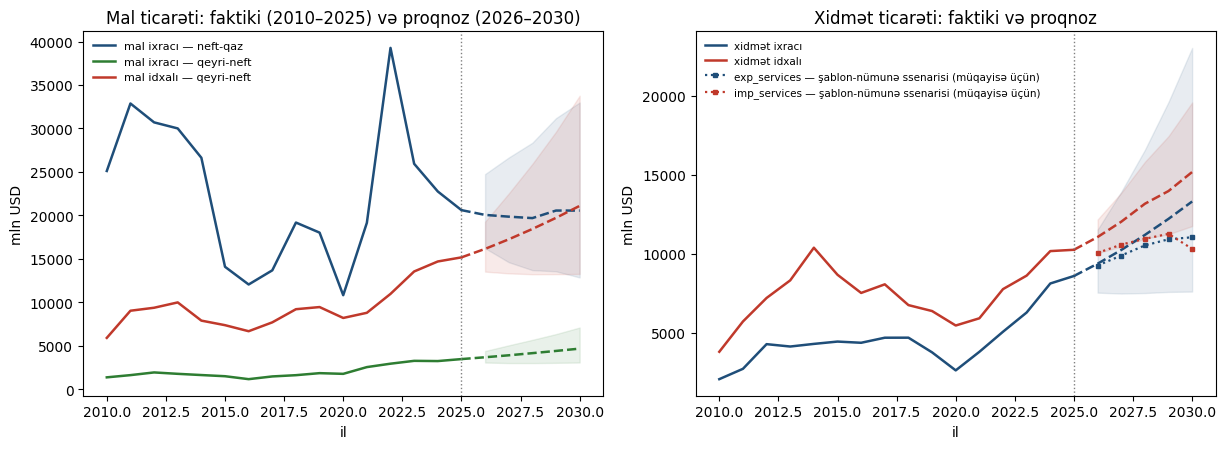

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

ax = axes[0]
for code_, colr, lbl in [("exp_goods_oil", "#1f4e79", "mal ixracı — neft-qaz"),
                         ("exp_goods_nonoil", "#2e7d32", "mal ixracı — qeyri-neft"),
                         ("imp_goods_nonoil", "#c0392b", "mal idxalı — qeyri-neft")]:
    ax.plot(S[code_].index, S[code_].values, "-", lw=1.8, color=colr, label=lbl)
    ax.plot([LA] + FY, [float(S[code_].loc[LA])] + list(central[code_].values), "--", lw=1.8, color=colr)
    ax.fill_between(FY, BAND[code_]["lo80"], BAND[code_]["hi80"], color=colr, alpha=0.10)
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Mal ticarəti: faktiki (2010–2025) və proqnoz (2026–2030)")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=8, loc="upper left")

ax = axes[1]
for code_, colr, lbl in [("exp_services", "#1f4e79", "xidmət ixracı"),
                         ("imp_services", "#c0392b", "xidmət idxalı")]:
    ax.plot(S[code_].index, S[code_].values, "-", lw=1.8, color=colr, label=lbl)
    ax.plot([LA] + FY, [float(S[code_].loc[LA])] + list(central[code_].values), "--", lw=1.8, color=colr)
    ax.fill_between(FY, BAND[code_]["lo80"], BAND[code_]["hi80"], color=colr, alpha=0.10)
for code_, colr in [("exp_services", "#1f4e79"), ("imp_services", "#c0392b")]:
    mbs = MB[code_]
    ax.plot(mbs.index, mbs.values, ":", lw=1.6, marker="s", ms=3.5, color=colr,
            label=f"{code_} — şablon-nümunə ssenarisi (müqayisə üçün)")
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Xidmət ticarəti: faktiki və proqnoz")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5, loc="upper left")

fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR07_ticaret.png"), dpi=140)
plt.show()

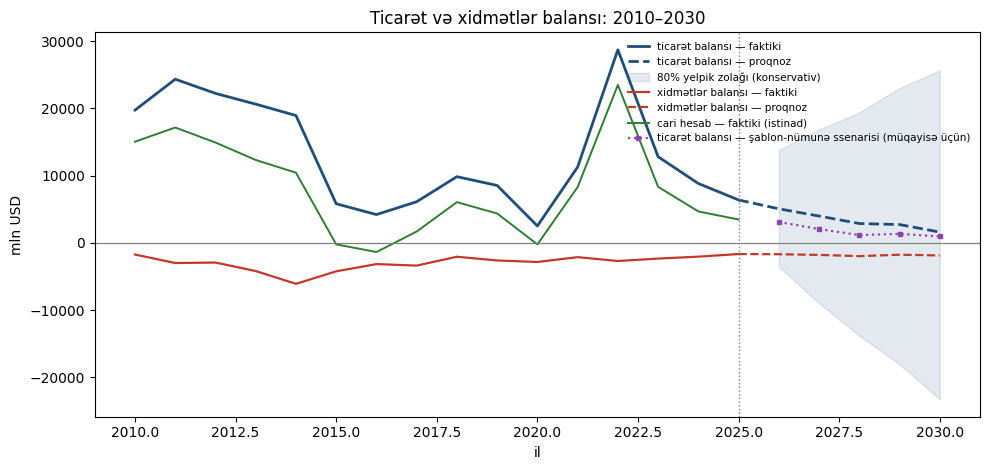

In [32]:
fig, ax = plt.subplots(figsize=(10.0, 4.8))
tb_h = S["trade_balance"]
ax.plot(tb_h.index, tb_h.values, "-", lw=2.0, color="#1f4e79", label="ticarət balansı — faktiki")
ax.plot([LA] + FY, [float(tb_h.loc[LA])] + list(central["trade_balance"].values), "--", lw=2.0,
        color="#1f4e79", label="ticarət balansı — proqnoz")
ax.fill_between(FY, BAND["trade_balance"]["lo80"], BAND["trade_balance"]["hi80"],
                color="#1f4e79", alpha=0.12, label="80% yelpik zolağı (konservativ)")
sb_h = S["services_balance"]
ax.plot(sb_h.index, sb_h.values, "-", lw=1.6, color="#c0392b", label="xidmətlər balansı — faktiki")
ax.plot([LA] + FY, [float(sb_h.loc[LA])] + list(central["services_balance"].values), "--", lw=1.6,
        color="#c0392b", label="xidmətlər balansı — proqnoz")
ca_h = S["current_account"]
ax.plot(ca_h.index, ca_h.values, "-", lw=1.4, color="#2e7d32", label="cari hesab — faktiki (istinad)")
ax.plot(MB.index, MB["trade_balance"].values, ":", lw=1.6, marker="s", ms=3.5, color="#8e44ad",
        label="ticarət balansı — şablon-nümunə ssenarisi (müqayisə üçün)")
ax.axhline(0, color="grey", lw=0.9)
ax.axvline(LA, color="grey", ls=":", lw=1)
ax.set_title("Ticarət və xidmətlər balansı: 2010–2030")
ax.set_ylabel("mln USD"); ax.set_xlabel("il")
ax.legend(frameon=False, fontsize=7.5, loc="upper right")
fig.tight_layout()
fig.savefig(os.path.join(config.FIG, "FR07_balanslar.png"), dpi=140)
plt.show()

### 7.4. Həssaslıq: iki açıq qərar

İki qərar mərkəzi yolu maddi şəkildə dəyişə bilər və ona görə ölçülür. Birincisi, neft-qaz
idxalının etalonla (2025 səviyyəsində sabit) saxlanması qərarı; alternativ sabit pay qaydasıdır.
İkincisi, REER-in rejim fərziyyəsi; alternativ xarici blok faylının öz yoludur.

In [33]:
k3 = float((S["imp_goods_oil"] / S["imp_goods_nonoil"]).iloc[-3:].mean())
alt_mo = pd.Series({y: k3 * float(central.loc[y, "imp_goods_nonoil"]) for y in FY})

reer_file = pd.concat([reer_hist.loc[[LA]], ext["reer"].loc[FY[0]:FY[-1]]])
dlreer_alt = (np.log(reer_file).diff() * 100.0).loc[FY]
DR_alt = DR.copy(); DR_alt.loc[FY, "dlreer"] = dlreer_alt.values


def path_growth_alt(code_, drivers, minn=6):
    d = DR.loc[:LA].copy(); d["y"] = S[code_]; d["g"] = np.log(d["y"]).diff() * 100.0
    fit = _fit(d, "g", drivers, minn)
    out, prev = {}, float(S[code_].loc[LA])
    for y in FY:
        g = fit.params["const"] + sum(fit.params[k] * DR_alt.loc[y, k] for k in drivers)
        prev = prev * np.exp(g / 100.0)
        out[y] = prev
    return out


alt_paths = dict(PATHS["imp_goods_nonoil"])
alt_paths["ABSORBSİYA+REER"] = path_growth_alt("imp_goods_nonoil", ["absorbsiya", "dlreer"])
mn_alt = BT["imp_goods_nonoil"].combine(alt_paths)

sens = pd.DataFrame({
    "mərkəzi: ticarət balansı": central["trade_balance"],
    "neft idxalı sabit pay ilə": central["trade_balance"] - (alt_mo - central["imp_goods_oil"]),
    "REER faylın yolu ilə": central["trade_balance"] - (mn_alt - central["imp_goods_nonoil"]),
}).round(1)
sens["fərq: pay qaydası"] = (sens.iloc[:, 1] - sens.iloc[:, 0]).round(1)
sens["fərq: REER"] = (sens.iloc[:, 2] - sens.iloc[:, 0]).round(1)
print("Xarici blok faylının REER artımı (%):",
      {int(y): round(float(v), 1) for y, v in dlreer_alt.items()})
# §7.4-ün mətnindəki iki rəqəm buradan oxunur — əl ilə yazılmış dəyər saxlanılmır
print(f"2030-cu ildə ticarət balansına təsir: sabit pay qaydası "
      f"{float(sens.loc[FY[-1], 'fərq: pay qaydası']):+.0f} mln USD, "
      f"faylın REER yolu {float(sens.loc[FY[-1], 'fərq: REER']):+.0f} mln USD "
      f"(mərkəzi yol {float(sens.loc[FY[-1], 'mərkəzi: ticarət balansı']):.0f} mln USD)")
sens

Xarici blok faylının REER artımı (%): {2026: 8.1, 2027: 4.2, 2028: 5.4, 2029: 5.7, 2030: 5.7}
2030-cu ildə ticarət balansına təsir: sabit pay qaydası -1304 mln USD, faylın REER yolu -984 mln USD (mərkəzi yol 1604 mln USD)


,mərkəzi: ticarət balansı,neft idxalı sabit pay ilə,REER faylın yolu ilə,fərq: pay qaydası,fərq: REER
2026,5061.8,4656.3,4859.4,-405.5,-202.4
2027,3986.5,3381.2,3656.8,-605.3,-329.7
2028,2874.9,2053.4,2363.6,-821.5,-511.3
2029,2720.0,1666.0,1989.8,-1054.0,-730.2
2030,1603.9,299.9,620.1,-1304.0,-983.8


Hər iki alternativ mərkəzi yolu **eyni istiqamətdə** dəyişir və heç biri nəticəni tərsinə çevirmir.
Sabit pay qaydası neft-qaz idxalını qeyri-neft idxalı ilə birlikdə artırdığı üçün 2030-cu ildə
ticarət balansını 1 304 mln USD azaldır; faylın öz REER yolu (2026-cı ildə +8,1 %, sonra ildə
4,2–5,7 %) idxalı bahalaşdırdığı üçün balansı 984 mln USD azaldır. Hər iki halda profisit 2030-cu
ildə müsbət qalır, lakin sıfıra daha yaxın olur. Bu, mərkəzi yolun ehtiyatlı tərəfdə deyil, iki
alternativin arasında olduğunu göstərir.

### 7.5. Neft qiyməti ssenariləri

FR12 tədiyə balansını neft qiymətinin yelpik kvantillərində yenidən həll edir. Bunun üçün neft
ixracının dəyəri FR5-in `brent_usd_lo80` və `brent_usd_hi80` yollarında bu dəftərin öz
dekompozisiya bloku ilə hesablanır və nəticə `forecast_long`-a ayrıca sıra kimi yazılır — beləliklə
aşağı axın tənliyi yenidən qurmadan eyni rəqəmi istifadə edir.

In [34]:
def oil_export_at(brent_path):
    """Neft ixracının dəyəri verilmiş Brent yolunda: qiymət tənliyi × kalibrlənmiş həcm."""
    out, Vc = {}, float(V.loc[LA])
    for y in FY:
        Vc = Vc * np.exp(float(DR.loc[y, "oilg"]) / 100.0)
        p = float(np.exp(lr_p["const"] + lr_p["lbr"] * np.log(float(brent_path.loc[y]))))
        out[y] = p * Vc
    return pd.Series(out)


scen = pd.DataFrame({
    "Brent aşağı (lo80)": A["brent_usd_lo80"].loc[FY],
    "Brent mərkəzi": A["brent_usd"].loc[FY],
    "Brent yuxarı (hi80)": A["brent_usd_hi80"].loc[FY],
    "X_neft — aşağı": oil_export_at(A["brent_usd_lo80"]),
    "X_neft — mərkəzi (dekompozisiya)": oil_export_at(A["brent_usd"]),
    "X_neft — yuxarı": oil_export_at(A["brent_usd_hi80"]),
})
scen.round(1)

,Brent aşağı (lo80),Brent mərkəzi,Brent yuxarı (hi80),X_neft — aşağı,X_neft — mərkəzi (dekompozisiya),X_neft — yuxarı
2026,46.5,69.0,102.7,12366.7,19400.9,30561.8
2027,39.0,69.0,121.9,9878.1,18956.2,36300.1
2028,34.4,69.4,141.1,8313.5,18544.5,41688.5
2029,30.5,69.5,158.8,7484.3,19160.0,49230.6
2030,27.5,69.2,174.0,6590.0,18912.1,54162.8


## 8. Nəticələrin ixracı

Üç çıxış faylı yazılır: proqnoz/faktiki sıralar (`outputs/forecast_long.csv`), tənlik kataloqu
(`outputs/equations_catalog.csv`) və artıq yuxarıda yazılmış sınaq nəticələri
(`outputs/validation_backtest.csv`). Bu dəftər `data/assumptions.csv`-ə yazmır: onun nəticələri
sürücü fərziyyəsi deyil, aşağı axının birbaşa oxuduğu proqnoz sıralarıdır. Sonda bütün eyniliklər
HƏR il üçün yoxlanılır.

In [35]:
cat_names = data_layer.catalog().set_index("series_code")
NAMES = {c: str(cat_names.loc[c, "name_az"]) for c in CODES + AGG}
NEW_SERIES = {
    "exp_goods_oil_brent_lo80": "Malların ixracı — neft-qaz, Brent aşağı ssenarisi (lo80)",
    "exp_goods_oil_brent_hi80": "Malların ixracı — neft-qaz, Brent yuxarı ssenarisi (hi80)",
    "oil_export_price_fr7": "Neftin ixrac qiyməti — FR7 tənliyinin proqnozu",
}

rows = []


def add(code_, name, unit, year, kind, source, value, band=None):
    rows.append({"fr": "FR7", "series_code": code_, "series_name_az": name, "unit": unit,
                 "year": int(year), "kind": kind, "source": source, "value": float(value),
                 "lo80": None if band is None else float(band["lo80"]),
                 "hi80": None if band is None else float(band["hi80"]),
                 "lo50": None if band is None else float(band["lo50"]),
                 "hi50": None if band is None else float(band["hi50"])})


for c in CODES + AGG:
    for y, v in S[c].items():                       # faktiki dəyərlər 2010–2025
        add(c, NAMES[c], "mln USD", y, "actual", "ours", v)
    for y in FY:                                    # proqnoz + yelpik zolaqları
        add(c, NAMES[c], "mln USD", y, "forecast", "ours", central.loc[y, c], BAND[c].loc[y])
    mb = MB[c].dropna()
    for y, v in mb.items():                         # şablon-nümunə ssenarisi (overlay)
        add(c, NAMES[c], "mln USD", y, "forecast", "template_sample", v)

for y, v in pe.items():
    add("oil_export_price_fr7", NEW_SERIES["oil_export_price_fr7"], "USD/barel", y, "actual", "ours", v)
for y in FY:
    add("oil_export_price_fr7", NEW_SERIES["oil_export_price_fr7"], "USD/barel", y, "forecast",
        "ours", pe_fc.loc[y])
for nm, col in [("exp_goods_oil_brent_lo80", "X_neft — aşağı"),
                ("exp_goods_oil_brent_hi80", "X_neft — yuxarı")]:
    for y in FY:
        add(nm, NEW_SERIES[nm], "mln USD", y, "forecast", "ours", scen.loc[y, col])

# --- Xidmət bölgüsü: xidmət alt sətirləri (faktiki + uzlaşdırılmış proqnoz + zolaq) ------------------
_serv_names = data_layer.catalog().set_index("series_code")
for _c in SERV_PARTS:
    _nm = (str(_serv_names.loc[_c, "name_az"]) if _c in _serv_names.index
           else {"exp_serv_other": "Xidmət ixracı — digər (tikinti, maliyyə, hökumət, qalıq)",
                 "imp_serv_other": "Xidmət idxalı — digər (tikinti, maliyyə, hökumət, qalıq)"}[_c])
    NEW_SERIES.setdefault(_c, _nm)
    for _y, _v in S[_c].items():
        add(_c, _nm, "mln USD", _y, "actual", "ours", _v)
    for _y in FY:
        add(_c, _nm, "mln USD", _y, "forecast", "ours", SERV_CENTRAL.loc[_y, _c],
            SERV_BAND[_c].loc[_y])
for _c in ["exp_serv_nonoil", "imp_serv_nonoil"]:
    _nm = str(_serv_names.loc[_c, "name_az"])
    NEW_SERIES.setdefault(_c, _nm)
    _pp = [p for p in (EXP_PARTS if _c.startswith("exp") else IMP_PARTS)
           if not p.endswith("_serv_oil")]
    for _y, _v in S[_c].items():
        add(_c, _nm, "mln USD", _y, "actual", "ours", _v)
    for _y in FY:
        add(_c, _nm, "mln USD", _y, "forecast", "ours", float(SERV_CENTRAL.loc[_y, _pp].sum()))
for _c, _nm, _ser in [("exp_serv_uzlasma", "Xidmət ixracının uzlaşdırma əmsalı (cəm ÷ alt sətirlər)",
                       SERV_K["exp"]),
                      ("imp_serv_uzlasma", "Xidmət idxalının uzlaşdırma əmsalı (cəm ÷ alt sətirlər)",
                       SERV_K["imp"])]:
    NEW_SERIES.setdefault(_c, _nm)
    for _y in FY:
        add(_c, _nm, "əmsal", _y, "forecast", "ours", float(_ser.loc[_y]))

fl = pd.DataFrame(rows)
outputs.write_forecast_long(fl)
print(f"forecast_long.csv-ə yazıldı: {len(fl)} sətir, {fl['series_code'].nunique()} sıra")
fl.head(3)

forecast_long.csv-ə yazıldı: 608 sətir, 29 sıra


,fr,series_code,series_name_az,unit,year,kind,source,value,lo80,hi80,lo50,hi50
0,FR7,exp_goods_oil,Malların ixracı — neft-qaz sektoru,mln USD,2010,actual,ours,25107.536,NaN,NaN,NaN,NaN
1,FR7,exp_goods_oil,Malların ixracı — neft-qaz sektoru,mln USD,2011,actual,ours,32871.018,NaN,NaN,NaN,NaN
2,FR7,exp_goods_oil,Malların ixracı — neft-qaz sektoru,mln USD,2012,actual,ours,30700.508,NaN,NaN,NaN,NaN


In [36]:
dict_rows = pd.DataFrame([
    {"series_code": "exp_goods_oil_brent_lo80", "name_az": NEW_SERIES["exp_goods_oil_brent_lo80"],
     "name_en": "Oil-gas goods exports, low Brent scenario", "unit": "mln USD", "fr": "FR7",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.13.-14."},
    {"series_code": "exp_goods_oil_brent_hi80", "name_az": NEW_SERIES["exp_goods_oil_brent_hi80"],
     "name_en": "Oil-gas goods exports, high Brent scenario", "unit": "mln USD", "fr": "FR7",
     "statutory_sheet_ref": "8 vərəq, 2.4.1.13.-14."},
    {"series_code": "oil_export_price_fr7", "name_az": NEW_SERIES["oil_export_price_fr7"],
     "name_en": "Oil export price, FR7 equation forecast", "unit": "USD/barel", "fr": "FR7",
     "statutory_sheet_ref": "Neft-Qaz sektoru, sətir 10"},
] + [
    {"series_code": c, "name_az": NEW_SERIES[c],
     "name_en": ("Services exports/imports component — " + c), "unit": "mln USD", "fr": "FR7",
     "statutory_sheet_ref": "Tədiyyə Balansı, sətirlər 15-54"}
    for c in SERV_PARTS + ["exp_serv_nonoil", "imp_serv_nonoil"]
] + [
    {"series_code": c, "name_az": NEW_SERIES[c],
     "name_en": "Services reconciliation factor (published total / bottom-up sum)",
     "unit": "əmsal", "fr": "FR7", "statutory_sheet_ref": "Tədiyyə Balansı, sətirlər 14/34"}
    for c in ["exp_serv_uzlasma", "imp_serv_uzlasma"]
])
outputs.write_series_dictionary(dict_rows)
print(f"series_dictionary.csv: {len(dict_rows)} yeni sıra qeydiyyata alındı")

series_dictionary.csv: 19 yeni sıra qeydiyyata alındı


In [37]:
WB = "Statistik data dinamika 05.06.2026 +.xlsx"
SH = "Tədiyyə Balansı"
cat_rows = pd.DataFrame([
    ecm_price.lr.catalog_row(
        eq_name="FR7_neft_ixrac_qiymeti_uzunmuddetli",
        description=("STRUKTUR: neftin ixrac qiyməti ilə Brent arasında uzunmüddətli əlaqə — "
                     "eg_coint ilə təsdiqlənmiş kointeqrasiya (p = 0,0001), elastiklik 1,141"),
        lhs="ln oil_export_price", series_code="oil_export_price", fr="FR7",
        workbook=WB, sheet="Neft-Qaz sektoru"),
    ecm_price.sr.catalog_row(
        eq_name="FR7_neft_ixrac_qiymeti_ecm",
        description=("STRUKTUR: xəta korreksiyası tənliyi — korreksiya əmsalı "
                     f"{ecm_price.alpha:.3f} (t = {ecm_price.alpha_t:.2f}), yarım-ömür 0,7 il"),
        lhs="Δ ln oil_export_price", series_code="oil_export_price", fr="FR7",
        workbook=WB, sheet="Neft-Qaz sektoru"),
    res_vol.catalog_row(
        eq_name="FR7_neft_ixrac_hecmi",
        description=("STRUKTUR: ixrac həcmi ~ hasilat planı; qiymətləndirilmiş elastiklik 2,08 "
                     "iqtisadi cəhətdən müdafiə oluna bilmədiyi üçün proqnozda vahid elastiklikli "
                     "kalibrlənmiş variant üstünlük qazanıb (sınaq nəticəsi)"),
        lhs="Δ ln V", series_code="exp_goods_oil", fr="FR7", workbook=WB, sheet=SH),
    res_xn.catalog_row(
        eq_name="FR7_qeyri_neft_ixrac_terefdas",
        description="STRUKTUR: qeyri-neft mal ixracı ~ tərəfdaş ölkələrin ÜDM artımı",
        lhs="Δ ln exp_goods_nonoil", series_code="exp_goods_nonoil", fr="FR7", workbook=WB, sheet=SH),
    res_xn_br.catalog_row(
        eq_name="FR7_qeyri_neft_ixrac_terefdas_brent",
        description=("STRUKTUR: qeyri-neft mal ixracı ~ tərəfdaş artımı + Δln Brent — ansamblda "
                     "ən böyük çəkiyə malik variant"),
        lhs="Δ ln exp_goods_nonoil", series_code="exp_goods_nonoil", fr="FR7", workbook=WB, sheet=SH),
    res_xn_reer.catalog_row(
        eq_name="FR7_qeyri_neft_ixrac_reer_sinagi",
        description=("SINAQ: REER əlavə edilmiş variant — əmsal (+0,89) iqtisadi cəhətdən səhv "
                     "işarədədir, ona görə proqnoz mərhələsinə buraxılmayıb"),
        lhs="Δ ln exp_goods_nonoil", series_code="exp_goods_nonoil", fr="FR7", workbook=WB, sheet=SH),
    res_mn.catalog_row(
        eq_name="FR7_qeyri_neft_idxal_absorbsiya",
        description=("STRUKTUR: qeyri-neft mal idxalı ~ daxili absorbsiyanın real artımı. "
                     "Absorbsiya = SON İSTEHLAK + İNVESTİSİYA (real, 2015 qiymətləri ilə); "
                     "yəni investisiya tənliyin sürücüsünün TƏRKİB HİSSƏSİDİR. "
                     "Tənlik: Δln M^qeyri = a + b·absorbsiya + c·Δln REER"),
        lhs="Δ ln imp_goods_nonoil", rhs="absorbsiya (son istehlak + investisiya, real)",
        series_code="imp_goods_nonoil", fr="FR7", workbook=WB, sheet=SH),
    res_mn_reer.catalog_row(
        eq_name="FR7_qeyri_neft_idxal_absorbsiya_reer",
        description=("STRUKTUR: qeyri-neft mal idxalı ~ absorbsiya + REER — REER əmsalı düzgün "
                     "işarədədir (+0,48), ona görə saxlanılıb. Absorbsiya = SON İSTEHLAK + "
                     "İNVESTİSİYA (real, 2015 qiymətləri ilə): investisiya kanalı bu tənliyin "
                     "İÇİNDƏDİR, ayrıca reqressor kimi görünmür."),
        lhs="Δ ln imp_goods_nonoil", rhs="absorbsiya (son istehlak + investisiya, real) + dlreer",
        series_code="imp_goods_nonoil", fr="FR7", workbook=WB, sheet=SH),
    res_xs.catalog_row(
        eq_name="FR7_xidmet_ixrac",
        description="STRUKTUR: xidmət ixracı ~ tərəfdaş artımı + qeyri-neft sektorunun artımı",
        lhs="Δ ln exp_services", series_code="exp_services", fr="FR7", workbook=WB, sheet=SH),
    res_xs_n.catalog_row(
        eq_name="FR7_xidmet_ixrac_qeyri_neft",
        description="STRUKTUR: xidmət ixracı ~ qeyri-neft sektorunun artımı",
        lhs="Δ ln exp_services", series_code="exp_services", fr="FR7", workbook=WB, sheet=SH),
    res_ms.catalog_row(
        eq_name="FR7_xidmet_idxal",
        description=("STRUKTUR: xidmət idxalı ~ qeyri-neft sektorunun artımı — dəftərin ən möhkəm "
                     "əlaqəsi, pandemiya epizoduna qarşı robustdur"),
        lhs="Δ ln imp_services", series_code="imp_services", fr="FR7", workbook=WB, sheet=SH),
    res_ms_ex.catalog_row(
        eq_name="FR7_xidmet_idxal_robustluk",
        description="ROBUSTLİK: xidmət idxalı tənliyi 2020–2021 illəri istisna edilmiş nümunədə",
        lhs="Δ ln imp_services", series_code="imp_services", fr="FR7", workbook=WB, sheet=SH),
])

# --- Xidmət bölgüsü: on iki xidmət alt sətri — QAZANAN və SINANMIŞ-UDUZAN spesifikasiyalar (D4) --------
_SERV_RATIONALE = {
    "exp_serv_transport": "boru kəməri tranziti + Orta Dəhliz yükü ← xarici ticarətin dəyər həcmi",
    "exp_serv_travel": "gələn turistlərin xərci ← FR02-nin turizm sahəsi (turist axınının vəkili)",
    "exp_serv_telecom": "beynəlxalq rabitə ← FR02-nin informasiya-rabitə sahəsi",
    "exp_serv_business": "İT/konsaltinq ixracı ← qeyri-neft ixracı və neft-qaz investisiyası",
    "exp_serv_oil": "neft-qaz sektorunun xidmət ixracı ← sektorun investisiya dövranı",
    "exp_serv_other": "tikinti/maliyyə/hökumət qalığı ← qeyri-neft sektorunun artımı",
    "imp_serv_transport": "yük daşınmasının idxalı ← xarici ticarətin dəyər həcmi",
    "imp_serv_travel": "gedən turistlərin xərci ← qeyri-neft sektorunun artımı (real gəlir vəkili)",
    "imp_serv_telecom": "rabitə xidmətlərinin idxalı ← informasiya-rabitə sahəsi",
    "imp_serv_business": "işgüzar xidmətlərin idxalı ← qeyri-neft artımı + neft-qaz investisiyası",
    "imp_serv_oil": "neft-qaz sektorunun xidmət idxalı ← sektorun investisiya və hasilat dövranı",
    "imp_serv_other": "tikinti/maliyyə/hökumət qalığı ← qeyri-neft sektorunun artımı",
}
_serv_cat = []
for _c in SERV_PARTS:
    _b = SBT[_c]
    for _m in sorted(_b.rmse):
        if _m == "RW" or _b.rmse[_m] is None:
            continue
        _sk = None if not _b.rw_rmse else (1 - _b.rmse[_m] / _b.rw_rmse) * 100
        _kept = _m in _b.weights
        _fr = _serv_frame(_c).loc[:LA]
        _n = int(_fr[["y"]].dropna().shape[0])
        _serv_cat.append({
            "workbook": WB, "sheet": SH, "eq_name": f"FR7_{_c}_{_m.lower()}",
            "description": (("STRUKTUR" if _kept else "SINANMIŞ (mərkəzi yola buraxılmayıb)")
                            + f": {_SERV_RATIONALE[_c]}; model {_m}, "
                            + f"RW-yə nisbətdə bacarıq {'n/a' if _sk is None else f'{_sk:+.1f} %'}"
                            + (f", ansambl çəkisi {_b.weights[_m]:.2f}" if _kept else "")),
            "lhs": f"Δ ln {_c}", "rhs": _SERV_RATIONALE[_c], "series_code": _c, "fr": "FR7",
            "sample_start": int(SERV_FIRST[_c]), "sample_end": int(LA),
            "adj_r2": None, "se_regression": (None if _b.rmse[_m] is None else round(_b.rmse[_m], 3)),
        })
cat_rows = pd.concat([cat_rows, pd.DataFrame(_serv_cat)], ignore_index=True)
outputs.write_equations_catalog(cat_rows)
print(f"equations_catalog.csv-ə yazıldı: {len(cat_rows)} tənlik")
cat_rows[["eq_name", "lhs", "rhs", "sample_start", "sample_end", "adj_r2", "se_regression"]]

equations_catalog.csv-ə yazıldı: 68 tənlik


/var/folders/m1/n0lvc6fx1j9dx120d3_pj4xr0000gr/T/ipykernel_6731/1817109641.py:106: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  cat_rows = pd.concat([cat_rows, pd.DataFrame(_serv_cat)], ignore_index=True)


,eq_name,lhs,rhs,sample_start,sample_end,adj_r2,se_regression
0,FR7_neft_ixrac_qiymeti_uzunmuddetli,ln oil_export_price,lbr,1997,2025,0.9746,0.1113
1,FR7_neft_ixrac_qiymeti_ecm,Δ ln oil_export_price,d_lbr + ec_l1,1998,2025,0.9469,0.0660
2,FR7_neft_ixrac_hecmi,Δ ln V,oilg,2013,2025,0.0705,13.1772
3,FR7_qeyri_neft_ixrac_terefdas,Δ ln exp_goods_nonoil,partner,2011,2025,0.1698,14.2747
4,FR7_qeyri_neft_ixrac_terefdas_brent,Δ ln exp_goods_nonoil,partner + dlbr,2011,2025,0.3952,12.1840
...,...,...,...,...,...,...,...
63,FR7_imp_serv_business_sürüşmə,Δ ln imp_serv_business,işgüzar xidmətlərin idxalı ← qeyri-neft artımı...,2010,2025,NaN,290.2650
64,FR7_imp_serv_other_pay,Δ ln imp_serv_other,tikinti/maliyyə/hökumət qalığı ← qeyri-neft se...,2010,2025,NaN,264.0430
65,FR7_imp_serv_other_qeyri̇neft,Δ ln imp_serv_other,tikinti/maliyyə/hökumət qalığı ← qeyri-neft se...,2010,2025,NaN,212.2880
66,FR7_imp_serv_other_sürüşmə,Δ ln imp_serv_other,tikinti/maliyyə/hökumət qalığı ← qeyri-neft se...,2010,2025,NaN,215.4270


In [38]:
v = validate.Verifier("FR07 — Xarici ticarət və tədiyə balansı")

ALL_Y = list(range(2010, FY[-1] + 1))
full = {}
for c in CODES:
    full[c] = pd.concat([S[c], central[c]])
full["exp_goods"] = full["exp_goods_oil"] + full["exp_goods_nonoil"]
full["imp_goods"] = full["imp_goods_oil"] + full["imp_goods_nonoil"]
full["trade_balance"] = full["exp_goods"] - full["imp_goods"]
full["services_balance"] = full["exp_services"] - full["imp_services"]

# 1–4. balans eynilikləri — 2010-2030-un HƏR ilində
v.identity("ixrac = neft + qeyri-neft (2010-2030)", full["exp_goods"],
           full["exp_goods_oil"] + full["exp_goods_nonoil"], tol=1e-9)
v.identity("idxal = neft + qeyri-neft (2010-2030)", full["imp_goods"],
           full["imp_goods_oil"] + full["imp_goods_nonoil"], tol=1e-9)
v.identity("ticarət balansı = ixrac - idxal (2010-2030)", full["trade_balance"],
           full["exp_goods"] - full["imp_goods"], tol=1e-9)
v.identity("xidmətlər balansı = xidmət ixracı - xidmət idxalı (2010-2030)", full["services_balance"],
           full["exp_services"] - full["imp_services"], tol=1e-9)

# 5. ixrac olunan sıralar faktiki hissədə mənbə ilə üst-üstə düşür
for c in CODES + AGG:
    v.identity(f"faktiki hissə mənbə ilə eynidir: {c}", full[c].loc[2010:LA], S[c], tol=1e-9)

# 6. neft ixracının dekompozisiya eyniliyi: dəyər = qiymət × həcm (faktiki illər)
v.identity("neft ixracı = ixrac qiyməti × həcm (2010-2025)", S["exp_goods_oil"],
           pe.reindex(V.index) * V, tol=1e-6)

# 7. ansambl çəkilərinin cəmi hər sıra üçün vahidə bərabərdir
for c in CODES:
    v.close(f"ansambl çəkilərinin cəmi = 1: {c}", sum(BT[c].weights.values()), 1.0, tol=1e-12)

# 8. mərkəzi yol çəkili cəmdir — müstəqil yenidən hesablama
for c in CODES:
    v.identity(f"mərkəzi yol = Σ çəki(m) × yol(m): {c}", central.loc[FY, c],
               pd.Series({y: sum(BT[c].weights[m] * PATHS[c][m][y] for m in BT[c].weights)
                          for y in FY}), tol=1e-9)

# 9. gələcəyə baxış yoxdur — bütün qiymətləndirmə nümunələri
for nm, res_ in [("neft ixrac qiyməti (uzunmüddətli)", ecm_price.lr), ("ixrac həcmi", res_vol),
                 ("qeyri-neft ixracı", res_xn_br), ("qeyri-neft idxalı", res_mn_reer),
                 ("xidmət ixracı", res_xs), ("xidmət idxalı", res_ms)]:
    v.ok(f"gələcəyə baxış yoxdur: {nm}", res_.sample[1] <= LA,
         f"nümunə {res_.sample[0]}–{res_.sample[1]}, n = {res_.n}")

# 10. yelpik zolağı mərkəzi yolu əhatə edir və genişlənir
for c in CODES:
    b = BAND[c]
    v.ok(f"yelpik zolağı mərkəzi yolu əhatə edir: {c}",
         bool((b["lo80"] <= central.loc[FY, c]).all() and (b["hi80"] >= central.loc[FY, c]).all()))
    v.ok(f"yelpik zolağı üfüq boyu genişlənir: {c}",
         bool((b["hi80"] - b["lo80"]).diff().dropna().gt(0).all()))

for c in CODES:
    v.ok(f"yelpik zolağının aşağı sərhədi müsbətdir: {c}", bool((BAND[c]["lo80"] > 0).all()))
for c in AGG:
    b = BAND[c]
    v.ok(f"məcmu göstəricinin zolağı mərkəzi yolu əhatə edir: {c}",
         bool(np.isfinite(b.values).all() and (b["lo80"] <= central.loc[FY, c]).all()
              and (b["hi80"] >= central.loc[FY, c]).all()))
    v.ok(f"məcmu göstəricinin zolağı ölçülü qalır (< 4 × səviyyə): {c}",
         bool(((b["hi80"] - b["lo80"]).abs()
               <= 4.0 * central.loc[FY, ["exp_goods", "imp_goods"]].abs().max(axis=1)).all()))

# 11. 2026-cı il neft ixracı tamamilə müstəqil kodla yenidən törədilir
def _yenidən_hesabla_2026():
    d = pd.DataFrame({"lp": np.log(pe), "lb": np.log(brent).reindex(pe.index)}).dropna()
    X = np.column_stack([np.ones(len(d)), d["lb"].values])
    bb = np.linalg.lstsq(X, d["lp"].values, rcond=None)[0]
    p26 = float(np.exp(bb[0] + bb[1] * np.log(float(A["brent_usd"].loc[2026]))))
    v26 = float(V.loc[LA]) * float(np.exp(float(A["oil_realg"].loc[2026]) / 100.0))
    parts = {"DEKOMPOZİSİYA_KALİBR": p26 * v26}
    for m, w in BT["exp_goods_oil"].weights.items():
        parts.setdefault(m, PATHS["exp_goods_oil"][m][2026])
    return sum(BT["exp_goods_oil"].weights[m] * parts[m] for m in BT["exp_goods_oil"].weights)

v.recompute("2026 neft-qaz ixracı (müstəqil yenidən hesablama)",
            float(central.loc[2026, "exp_goods_oil"]), _yenidən_hesabla_2026, tol=1e-6)

# 12. REER lövbəri məhz 2025 ilinə istinad edir
v.ok("REER lövbəri 2025 ilinə istinad edir (avtomatik son müşahidə deyil)",
     REER_ANCHOR_YEAR == LA and abs(reer_anchor - float(ext["reer"].loc[LA])) < 1e-12,
     f"lövbər ili {REER_ANCHOR_YEAR}, dəyər {reer_anchor:.4f}")

# 13. Xidmət bölgüsü — xidmət bölgüsünün AQREQASİYA eyniliyi, 2010–2030-un HƏR ilində
_exp_full = pd.concat([pd.DataFrame({c: S[c] for c in EXP_PARTS}), SERV_CENTRAL[EXP_PARTS]])
_imp_full = pd.concat([pd.DataFrame({c: S[c] for c in IMP_PARTS}), SERV_CENTRAL[IMP_PARTS]])
v.identity("xidmət ixracı = altı komponentin cəmi (2010-2030)",
           full["exp_services"], _exp_full.sum(axis=1), tol=1e-6)
v.identity("xidmət idxalı = altı komponentin cəmi (2010-2030)",
           full["imp_services"], _imp_full.sum(axis=1), tol=1e-6)
v.identity("xidmət ixracı = neft-qaz + qeyri-neft (2010-2030)", full["exp_services"],
           _exp_full["exp_serv_oil"] + _exp_full[[c for c in EXP_PARTS
                                                  if c != "exp_serv_oil"]].sum(axis=1), tol=1e-6)
for _c in SERV_PARTS:
    v.ok(f"alt sətrin zolağı mərkəzi yolu əhatə edir: {_c}",
         bool((SERV_BAND[_c]["lo80"] <= SERV_CENTRAL.loc[FY, _c]).all()
              and (SERV_BAND[_c]["hi80"] >= SERV_CENTRAL.loc[FY, _c]).all()))
    v.close(f"ansambl çəkilərinin cəmi = 1: {_c}", sum(SBT[_c].weights.values()), 1.0, tol=1e-12)
v.ok("uzlaşdırma əmsalı ağlabatan aralıqdadır (0,7-1,4)",
     bool(SERV_K["exp"].between(0.7, 1.4).all() and SERV_K["imp"].between(0.7, 1.4).all()),
     f"ixrac {SERV_K['exp'].min():.3f}-{SERV_K['exp'].max():.3f}, "
     f"idxal {SERV_K['imp'].min():.3f}-{SERV_K['imp'].max():.3f}")

v.assert_all()

  YOXLAMA: FR07 — Xarici ticarət və tədiyə balansı
  [PASS] eynilik: ixrac = neft + qeyri-neft (2010-2030)
         21 il, maksimal fərq 0.000e+00
  [PASS] eynilik: idxal = neft + qeyri-neft (2010-2030)
         21 il, maksimal fərq 0.000e+00
  [PASS] eynilik: ticarət balansı = ixrac - idxal (2010-2030)
         21 il, maksimal fərq 0.000e+00
  [PASS] eynilik: xidmətlər balansı = xidmət ixracı - xidmət idxalı (2010-2030)
         21 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə mənbə ilə eynidir: exp_goods_oil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə mənbə ilə eynidir: exp_goods_nonoil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə mənbə ilə eynidir: imp_goods_oil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə mənbə ilə eynidir: imp_goods_nonoil
         16 il, maksimal fərq 0.000e+00
  [PASS] eynilik: faktiki hissə mənbə ilə eynidir: exp_services
         16 il, maksimal fərq 0.000e+00
  [PA

In [39]:
# Yazılmış sətirlərin diskdə həqiqətən yerləşdiyinin yoxlanması
fl_disk = pd.read_csv(os.path.join(config.OUT, "forecast_long.csv"))
eq_disk = pd.read_csv(os.path.join(config.OUT, "equations_catalog.csv"))
bt_disk = pd.read_csv(os.path.join(config.OUT, "validation_backtest.csv"))
d7 = fl_disk[fl_disk["fr"] == "FR7"]
print("forecast_long.csv, FR7 sətirləri:      ", len(d7))
print("  sıralar:", sorted(d7["series_code"].unique()))
print("  proqnoz sətirləri (ours):            ",
      int(((d7["kind"] == "forecast") & (d7["source"] == "ours")).sum()))
print("  şablon overlay sətirləri:            ",
      int((d7["source"] == "template_sample").sum()))
print("equations_catalog.csv, FR7 sətirləri:  ", int((eq_disk["fr"] == "FR7").sum()))
print("validation_backtest.csv, FR7 sıraları: ",
      int(bt_disk["series_code"].isin(CODES).sum()))
print("\nFR11/FR12 üçün tələb olunan sıraların hamısı yerindədir:",
      all(c in set(d7["series_code"]) for c in CODES + AGG))

forecast_long.csv, FR7 sətirləri:       608
  sıralar: ['exp_goods', 'exp_goods_nonoil', 'exp_goods_oil', 'exp_goods_oil_brent_hi80', 'exp_goods_oil_brent_lo80', 'exp_serv_business', 'exp_serv_nonoil', 'exp_serv_oil', 'exp_serv_other', 'exp_serv_telecom', 'exp_serv_transport', 'exp_serv_travel', 'exp_serv_uzlasma', 'exp_services', 'imp_goods', 'imp_goods_nonoil', 'imp_goods_oil', 'imp_serv_business', 'imp_serv_nonoil', 'imp_serv_oil', 'imp_serv_other', 'imp_serv_telecom', 'imp_serv_transport', 'imp_serv_travel', 'imp_serv_uzlasma', 'imp_services', 'oil_export_price_fr7', 'services_balance', 'trade_balance']
  proqnoz sətirləri (ours):             145
  şablon overlay sətirləri:             50
equations_catalog.csv, FR7 sətirləri:   68
validation_backtest.csv, FR7 sıraları:  252

FR11/FR12 üçün tələb olunan sıraların hamısı yerindədir: True


## 9. Məhdudiyyətlər

**Xidmət bölgüsünün üç açıq məhdudiyyəti.** (i) Neft-qaz **ixrac** tərəfində vərəqdə
yalnız bir alt sətir var (`bop_r016` Yük daşımaları), ona görə tam «sahə × neft/qeyri-neft»
şəbəkəsi bu tərəfdə mövcud DEYİL; sorğu Annex 2, sətir 12-dədir. (ii) Dörd alt sətir
(emal-təmir, royalti, sığorta, şəxsi-mədəni xidmətlər) yalnız 2022-ci ildən doldurulub —
15 rüblük müşahidə ilə elastiklik qiymətləndirilmir, ona görə onlar *qalıq* komponentin
içindədir və ayrıca nəşr olunmur. (iii) `exp_serv_oil` sətri 2010–2014-cü illərdə sıfırdır;
onun tənliyi 2015-dən qiymətləndirilir və sınaq pəncərəsi cəmi beş ildir — nəticə göstərici
xarakterlidir, güclü sübut deyil.

**Uzlaşdırma əmsalı düzəliş deyil, ölçüdür.** Alt sətirlərin cəmi ilə nəşr olunan cəm
arasındakı fərq (ixracda 2030-cu ilə qədər təxminən 10 %-ə çatır) gizlədilmir və
`exp_serv_uzlasma` / `imp_serv_uzlasma` sıraları ilə nəşr olunur. Fərqin mənbəyi aydındır:
aqreqat tənliklər qeyri-neft artımına, alt sətirlər isə öz sürücülərinə reaksiya verir və
üfüq uzandıqca iki yol ayrılır. Onları məcburi bərabərləşdirmək yerinə fərq ölçülür.


**Nümunə uzunluğu.** Tədiyə balansı sıraları 2010-cu ildə başlayır (n = 16), fərq formasında isə
n = 15-ə enir. Bu, illik makro məlumat üçün adi vəziyyətdir, lakin əmsalların dəqiqliyini
məhdudlaşdırır və struktur sınıq nöqtələrinin (2015–2016 devalvasiyası, 2020 pandemiyası) süni
dəyişənlə ayrıca modelləşdirilməsinə imkan vermir: §0-ın n ≥ 15 qaydası formal olaraq ödənilsə də,
üç-dörd parametrli tənlikdə əlavə süni dəyişən sərbəstlik dərəcəsini praktiki olaraq tükədir.
Xidmət tənliklərində (n = 13) pandemiya epizodu ayrıca yoxlanılıb və nəticəyə təsir etmədiyi
göstərilib; mal ticarəti tənliklərində belə bir yoxlama aparılmayıb, çünki 2015–2016
devalvasiyasının təsiri artıq absorbsiya sürücüsünün öz dinamikasında əks olunur.

**DATA-GAP: ixrac həcminin müstəqil ölçüsü yoxdur.** Neft ixracının fiziki həcmi (barel və ya ton
ilə) tədiyə balansı vərəqində yoxdur; istifadə olunan həcm göstəricisi dəyərin ixrac qiymətinə
bölünməsi ilə alınıb və ona görə ixrac qiymətinin ölçmə xətasını əks tərəfə keçirir. Statutar
şablonun natural göstəricilər vərəqindəki hasilat sıraları (2.4.1.4., sətir 35 və 36) 2024-cü ildə
bitdiyi üçün onlarla əvəzlənə bilməyib.

**DATA-GAP: REER sırasının mənbəyi.** `external_block_annual.csv` faylının NEER və REER sütunlarının
hesablanma metodologiyası (çəki səbəti, baza ili) sənədləşdirilməyib. Sıra dəftərdə yalnız sınaq
dəyişəni kimi istifadə olunur və proqnoz üfüqündə rejim fərziyyəsi ilə sabit saxlanılır, ona görə
onun bu qeyri-müəyyənliyi mərkəzi yola keçmir; qeyri-neft ixracı tənliyində əmsalın səhv işarəsi
məhz bu sıranın neft dövrü ilə birgə hərəkəti ilə izah olunur.

**Şərti proqnoz.** Bütün ticarət tənlikləri şərti proqnoz verir: onların dəqiqliyi yuxarı axının
(FR5-in Brent yolu, FR1-in absorbsiya və qeyri-neft artımı yolları, IMF WEO-nun tərəfdaş artımı)
dəqiqliyindən asılıdır. Geriyə doğru sınaq da bu şərtdə aparılıb, yəni bacarıq rəqəmləri "sürücülər
düzgün proqnozlaşdırılarsa" oxunmalıdır. Bölmə 7.5-in neft qiyməti ssenariləri bu asılılığın ən
böyük hissəsini kəmiyyətcə göstərir.

**Neft-qaz idxalı üçün davranış modeli yoxdur.** Maddə etalonla (2025 səviyyəsində sabit)
saxlanılır, çünki üç alternativ qaydanın heç biri sınaqda etalonu üstələməyib. Bu, maddənin
proqnozlaşdırıla bilməməsinin açıq etirafıdır; Bölmə 7.4 sabit pay qaydasının nəticəyə təsirini
ölçür.

**Balansların yelpik zolağı konservativdir.** Ticarət və xidmətlər balansının zolağı komponent
xətaları arasında tam korrelyasiya fərziyyəsi ilə qurulub və ona görə həqiqi qeyri-müəyyənlikdən
genişdir. Praktikada ixrac və idxal xətaları eyni istiqamətdə hərəkət edir (hər ikisi neft dövrü
ilə bağlıdır), yəni balansın xətası komponentlərin xətalarından kiçikdir; dar zolağın verilməsi
üçün isə xətalar arasındakı korrelyasiya birbaşa ölçülməli idi, bu isə mövcud sınaq pəncərəsində
(7–9 il) etibarlı alınmır.